### Dataset: https://networkrepository.com/networks.php

In [1]:
import os
import subprocess
import shutil
import io
import requests
import zipfile
import lzma

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
subprocess.run(["g++", "generate-variate-graph.cpp", "-O3", "-o", "generate-variate-graph"], check=True, text=True, capture_output=True)

CompletedProcess(args=['g++', 'generate-variate-graph.cpp', '-O3', '-o', 'generate-variate-graph'], returncode=0, stdout='', stderr='')

In [1]:
def save_graph_nx(graph: nx.Graph, filename: str) -> None:
    try:
        with open(filename, "w") as f:
            for edge in graph.edges():
                f.write(f"{edge[0] + 1} {edge[1] + 1}\n")
    except Exception as e:
        print(f"Error saving graph to {filename}: {e}")

def load_graph_nx(filename: str) -> nx.Graph:
    graph = nx.Graph()
    try:
        with open(filename, "r") as f:
            for line in f:
                u, v = map(int, line.strip().split())
                graph.add_edge(u, v)
    except Exception as e:
        print(f"Error loading compressed graph from {filename}: {e}")
    return graph

def save_compressed_graph_nx(graph: nx.Graph, filename: str) -> None:
    try:
        with lzma.open(filename, "wt") as f:
            for edge in graph.edges():
                f.write(f"{edge[0] + 1} {edge[1] + 1}\n")
    except Exception as e:
        print(f"Error saving compressed graph to {filename}: {e}")

def load_compressed_graph_nx(filename: str) -> nx.Graph:
    graph = nx.Graph()
    try:
        with lzma.open(filename, "rt") as f:
            for line in f:
                u, v = map(int, line.strip().split())
                graph.add_edge(u - 1, v - 1)
    except Exception as e:
        print(f"Error loading compressed graph from {filename}: {e}")
    return graph

def relabel_graph_nx(graph: nx.Graph) -> nx.Graph:
    mapping = {old_label: new_label for new_label, old_label in enumerate(graph.nodes())}
    return nx.relabel_nodes(graph, mapping)

def count_subgraphs(graph: nx.Graph, subgraph: nx.Graph, nthreads: int) -> int:
    save_graph_nx(relabel_graph_nx(graph), "graph.txt")
    save_graph_nx(relabel_graph_nx(subgraph), "subgraph.txt")

    try:
        result = subprocess.run(
            ["./peregrine/bin/count", "graph.txt", "subgraph.txt", str(nthreads)],
            check=True,
            text=True,
            capture_output=True,
        )
        
        os.remove("graph.txt")
        os.remove("subgraph.txt")

        return int(result.stdout.split(":")[2].strip())
    except:
        os.remove("graph.txt")
        os.remove("subgraph.txt")
        
        print("Error occurred while counting subgraphs")
        return -1

NameError: name 'nx' is not defined

In [4]:
def generate_variate_graph(n: int, m: int, p: float, alpha: float | None = None, graph_type: str = "standard", file_identifier: str = "") -> nx.Graph:
    if graph_type == "standard":
        graph_type = "0"
    elif graph_type == "power-based":
        if alpha is None:
            print("Alpha parameter must be provided for power-based graph type")
            return None
        graph_type = "1"
    elif graph_type == "log-based":
        graph_type = "2"
    else:
        print(f"Graph type {graph_type} is not supported")
        return None

    result = subprocess.run(
            ["./generate-variate-graph", str(n), str(m), str(p), graph_type, f"graph_{file_identifier}.txt"] if alpha is None else
            ["./generate-variate-graph", str(n), str(m), str(p), graph_type, f"graph_{file_identifier}.txt", str(alpha)],
            check=True,
            text=True,
            capture_output=True,
        )
    
    if result.returncode != 0:
        print(f"Error generating graph: {result.stderr}")
        return None

    g = load_graph_nx(f"graph_{file_identifier}.txt")
    os.remove(f"graph_{file_identifier}.txt")
    
    return g

In [5]:
def calculate_empirical_degrees_connection_probability(gen_graph_func: callable, reps: int) -> defaultdict:
    degree_count_matrix = defaultdict(int)

    for _ in range(reps):
        G = gen_graph_func()
        
        for u, v in G.edges():
            deg_u = G.degree(u)
            deg_v = G.degree(v)
            degree_count_matrix[tuple(sorted((deg_u, deg_v)))] += 1

    degree_count_matrix_sum = sum(degree_count_matrix.values())
    degree_probability_matrix = defaultdict(float)
    for deg_pair, count in degree_count_matrix.items():
        degree_probability_matrix[deg_pair] = count / degree_count_matrix_sum

    return degree_probability_matrix

In [6]:
def calculate_structural_log_likelihood(G: nx.Graph, empirical_degrees_connection_probability: defaultdict) -> float:
    likelihood = 0
    for u, v in G.edges():
        deg_u = G.degree(u)
        deg_v = G.degree(v)

        if deg_u > deg_v:
            deg_u, deg_v = deg_v, deg_u

        if (deg_u, deg_v) in empirical_degrees_connection_probability:
            prob = empirical_degrees_connection_probability.get((deg_u, deg_v))
        else:
            neighbor_probs = []
            dist = 1
            while len(neighbor_probs) == 0:
                # |d1| + |d2| = dist
                for d1 in range(-dist, dist + 1):
                    for d2 in [dist - abs(d1), abs(d1) - dist]:
                        new_deg_u = deg_u + d1
                        new_deg_v = deg_v + d2

                        if new_deg_u > new_deg_v:
                            new_deg_u, new_deg_v = new_deg_v, new_deg_u

                        if (new_deg_u, new_deg_v) in empirical_degrees_connection_probability:
                            neighbor_probs.append(empirical_degrees_connection_probability[(new_deg_u, new_deg_v)])

                dist += 1
            prob = sum(neighbor_probs) / len(neighbor_probs)

        likelihood += np.log(prob)

    return likelihood

def compare_structural_log_likelihoods(G: nx.Graph, empirical_conn_probs: dict) -> dict:
    likelihoods = {}
    for model_name, emp_conn_prob in empirical_conn_probs.items():
        likelihood = calculate_structural_log_likelihood(G, emp_conn_prob)
        likelihoods[model_name] = likelihood

    return likelihoods, max(likelihoods, key=likelihoods.get)

In [7]:
def download_network(category: str, name: str) -> nx.Graph | None:
    url = "https://nrvis.com/./download/data/{category}/{name}.zip"

    response = requests.get(url.format(category=category, name=name), headers={})
    if response.status_code == 200:
        print(f"Successfully downloaded {name} network.")

        extract_dir = f"{name}-tmp-dir"
        network_edges_file = None
        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(io.BytesIO(response.content)) as z:
            network_edges_file = next((f for f in z.namelist() if f.startswith(name)), None)
            z.extractall(extract_dir)
        
        if not network_edges_file:
            print(f"Could not find the network edges file in the zip for {name}.")
            return None
        
        network = nx.Graph()
        with open(os.path.join(extract_dir, network_edges_file), 'r') as f:
            network_edges = [line.strip().split() for line in f if line.strip()]
            for edge_nodes in network_edges:
                if len(edge_nodes) < 2:
                    continue

                if not network.has_edge(edge_nodes[0], edge_nodes[1]):
                    network.add_edge(edge_nodes[0], edge_nodes[1])

        shutil.rmtree(extract_dir, ignore_errors=True)

        return network

    else:
        print(f"Failed to download {name} network. Status code: {response.status_code}")
        return None

In [31]:
def match_network_model(network: nx.Graph, models: list[dict]):
    print(f"Network has {network.number_of_nodes()} nodes and {network.number_of_edges()} edges.")

    if network.number_of_nodes() < 5 or network.number_of_edges() < 5:
        print("Network is too small to analyze degree distribution.")
        return
    
    def prepare_data(graph: nx.Graph):
        degrees = [degree for _, degree in graph.degree()]
        degree_counts = {}
        for degree in degrees:
            if degree in degree_counts:
                degree_counts[degree] += 1
            else:
                degree_counts[degree] = 1
        degree_values = list(degree_counts.keys())
        frequency_values = [degree_counts[degree] for degree in degree_values]

        return degrees, degree_values, frequency_values
    
    total_plots_number = len(models) + 1
    fig, axs = plt.subplots(2, total_plots_number, figsize=(5 * total_plots_number, 10))

    d1, dv1, fv1 = prepare_data(network)
    axs[0][0].hist(d1, bins=range(1, max(d1) + 1), density=True)
    axs[1][0].scatter(dv1, fv1)
    axs[1][0].set_xscale('log')
    axs[1][0].set_yscale('log')
    for index in range(1, total_plots_number):
        model = models[index - 1]
        artifical_network = generate_variate_graph(network.number_of_nodes(), int(network.number_of_edges() / network.number_of_nodes() + 0.5), 1, graph_type=model["name"])
        d2, dv2, fv2 = prepare_data(artifical_network)
        axs[0][index].hist(d2, bins=range(1, max(d2) + 1), density=True)
        axs[1][0].scatter(dv2, fv2, label=model["name"])
        # axs[1][index].set_xscale('log')
        # axs[1][index].set_yscale('log')

    fig.show()
    
    # plt.title("Degree Distribution")
    # plt.xlabel("Degree")
    # plt.ylabel("Frequency")
    # plt.show()

    
    # plt.title("Degree Distribution (Log-Log Scale)")
    # plt.xlabel("Degree")
    # plt.ylabel("Frequency")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.show()

Successfully downloaded bio-HS-CX network.
Network has 4413 nodes and 108818 edges.


/tmp/ipykernel_433956/1891284802.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


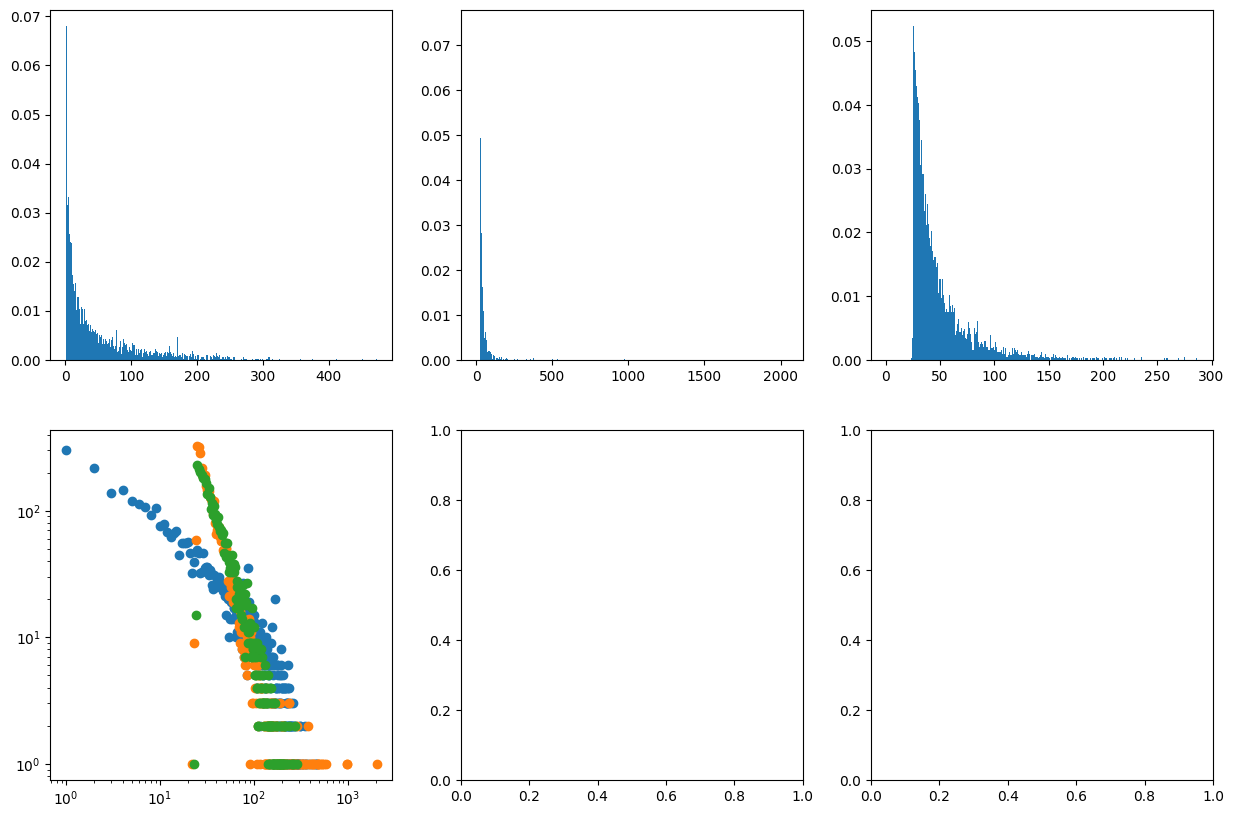

In [34]:
# network = download_network("bio", "bio-CE-CX")
network = download_network("bio", "bio-HS-CX")
# network = download_network("bio", "bio-CE-LC")
# network = download_network("bio", "bio-DM-LC")

match_network_model(network, [{"name": "standard"}, {"name": "log-based"}])

In [12]:
DATASET = {
    "bio": [
        "bio-MUTAG-g1",
        "bio-DM-LC",
        "bio-diseasome",
        "bio-celegans",
        "bio-yeast",
        "bio-celegans-dir",
        "bio-CE-LC",
        "bio-grid-mouse",
        "bio-yeast-protein-inter",
        "bio-grid-plant",
        "bio-CE-HT",
        "bio-SC-TS",
        "bio-CE-GT",
        "bio-grid-worm",
        "bio-DM-HT",
        "bio-grid-fission-yeast",
        "bio-dmela",
        "bio-HS-HT",
        "bio-grid-fruitfly",
        "bio-SC-LC",
        "bio-WormNet-v3-benchmark",
        "bio-grid-human",
        "bio-SC-CC",
        "bio-SC-GT",
        "bio-HS-LC",
        "bio-CE-PG",
        "bio-CE-GN",
        "bio-SC-HT",
        "bio-DM-CX",
        "bio-grid-yeast",
        "bio-DR-CX",
        "bio-HS-CX",
        "bio-CE-CX",
        "bio-WormNet-v3",
    ],
    "bn": [
        "bn-mouse-visual-cortex-1",
        "bn-cat-mixed-species-brain-1",
        "bn-macaque-rhesus-brain-2",
        "bn-macaque-rhesus-cerebral-cortex-1",
        "bn-macaque-rhesus-interrareak0cirticak-network-2",
        "bn-mouse-visual-cortex-2",
        "bn-mouse-brain-1",
        "bn-macaque-rhesus-brain-1",
        "bn-mouse-kasthuri-graph-v4",
        "bn-mouse-retina-1",
        "bn-fly-dropsophilia-medulla-1"
    ],
    "asn": [
        "aves-wildbird-network",
        "insecta-ant-colony6-day09",
        "insecta-ant-colony3-day02",
        "insecta-ant-colony5-day01",
        "insecta-ant-colony2-day07",
        "mammalia-voles-bhp-trapping",
        "mammalia-voles-rob-trapping",
        "mammalia-voles-kcs-trapping",
        "mammalia-voles-pij-trapping",
        "mammalia-dolphin-florida-overall",
        "aves-wildbird-network-6",
        "aves-wildbird-network-5",
        "aves-wildbird-network-4",
        "aves-wildbird-network-3",
        "aves-wildbird-network-2",
        "aves-wildbird-network-1",
        "aves-weaver-social",
        "aves-thornbill-farine",
        "aves-songbird-social",
        "aves-sparrow-social",
        "aves-geese-male-foraging"
    ],
    "ca": [
        "ca-sandi-auths",
        "ca-netscience",
        "ca-CSphd",
        "ca-Erdos992",
        "ca-GrQc",
        "ca-CondMat",
        "ca-HepPh",
        "ca-AstroPh"
    ],
    "soc": [
        "soc-tribes",
        "soc-firm-hi-tech",
        "soc-karate",
        "soc-dolphins",
        "soc-wiki-Vote",
        "soc-pages-food",
        "soc-hamsterster",
        "soc-pages-tvshow",
        "soc-advogato",
        "soc-anybeat",
        "soc-pages-politician"
    ],
    "email": [
        "email-enron-only",
        "email-dnc-corecipient",
        "email-univ",
        "email-dnc",
        "email-EU",
        "email-enron-large"
    ],
    "econ": [
        "econ-wm1",
        "econ-wm2",
        "econ-wm3",
        "econ-poli",
        "econ-mahindas",
        "econ-poli-large",
        "econ-mbeause",
        "econ-beause",
        "econ-mbeaflw",
        "econ-mbeacxc",
        "econ-beacxc",
        "econ-beaflw",
        "econ-orani678"
    ]
}

bio, bio-MUTAG-g1
Failed to download bio-MUTAG-g1 network. Status code: 404
bio, bio-DM-LC
Successfully downloaded bio-DM-LC network.
Network has 658 nodes and 1129 edges.


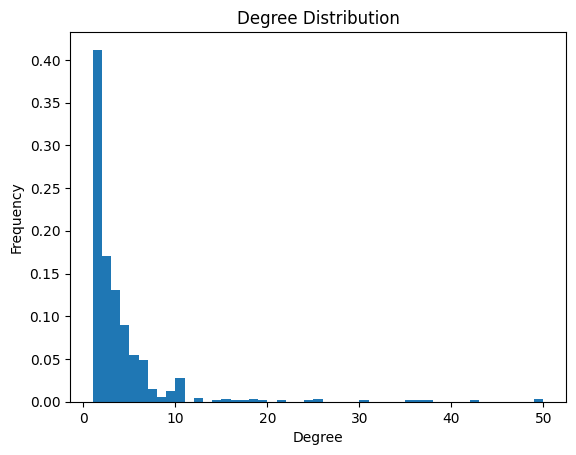

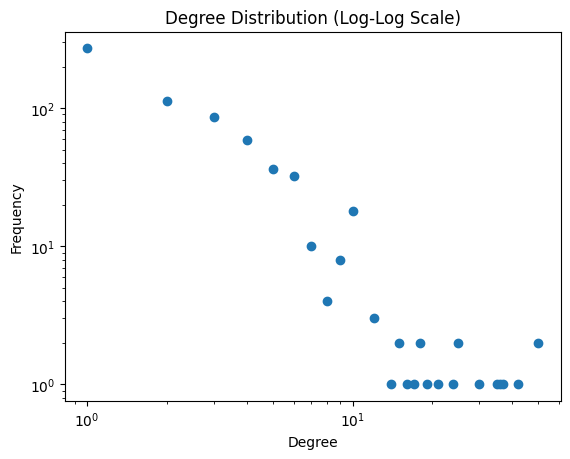

bio, bio-diseasome
Successfully downloaded bio-diseasome network.
Network has 518 nodes and 1190 edges.


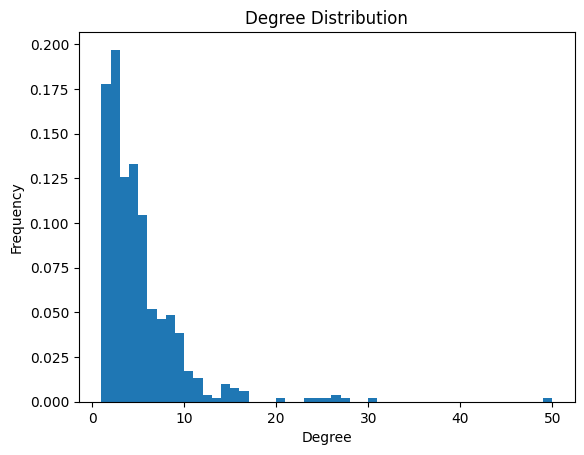

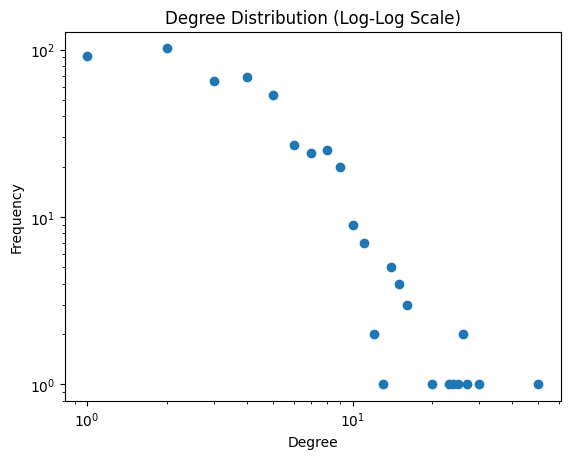

bio, bio-celegans
Successfully downloaded bio-celegans network.
Network has 455 nodes and 2027 edges.


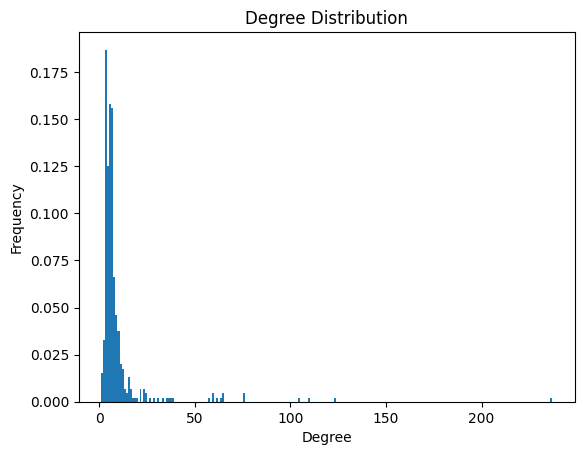

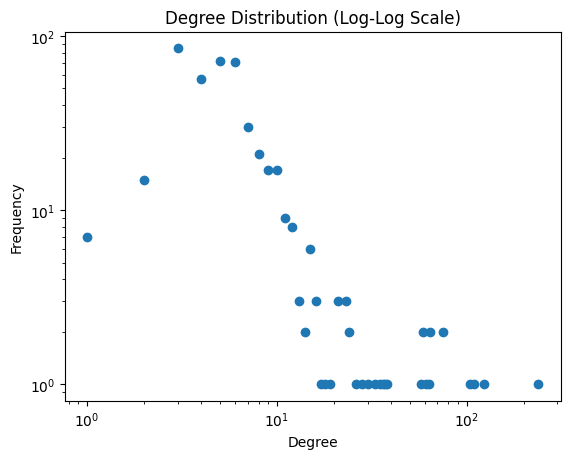

bio, bio-yeast
Successfully downloaded bio-yeast network.
Network has 1460 nodes and 1950 edges.


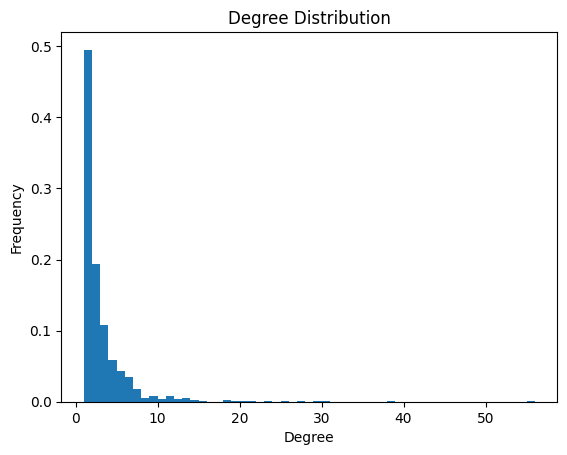

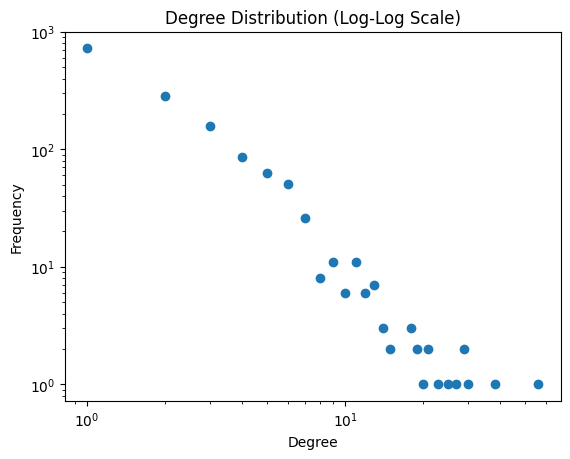

bio, bio-celegans-dir
Successfully downloaded bio-celegans-dir network.
Network has 453 nodes and 2040 edges.


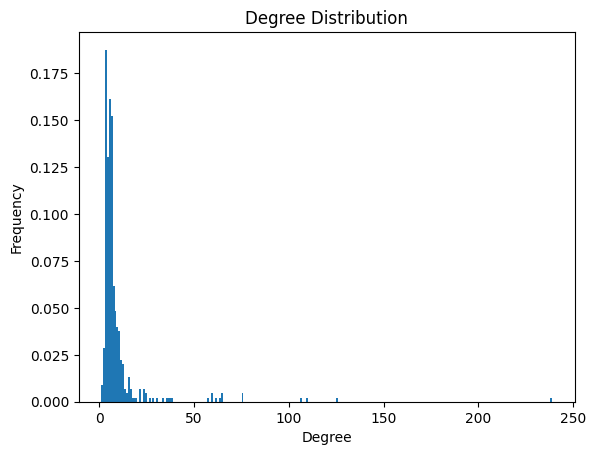

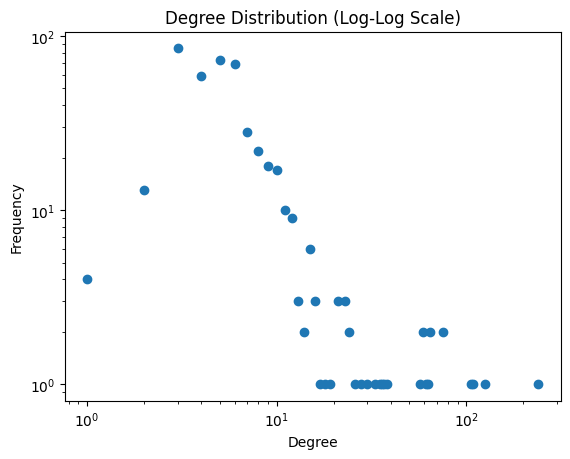

bio, bio-CE-LC
Successfully downloaded bio-CE-LC network.
Network has 1387 nodes and 1648 edges.


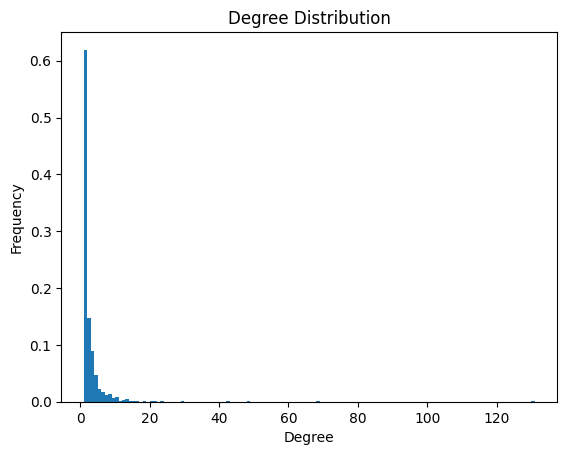

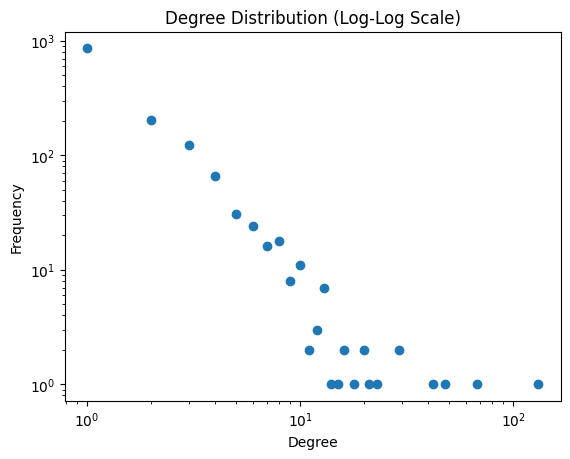

bio, bio-grid-mouse
Successfully downloaded bio-grid-mouse network.
Network has 2 nodes and 1 edges.
Network is too small to analyze degree distribution.
bio, bio-yeast-protein-inter
Successfully downloaded bio-yeast-protein-inter network.
Network has 1870 nodes and 2277 edges.


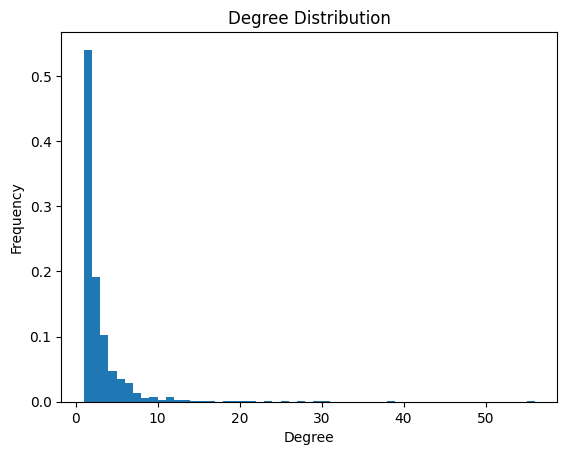

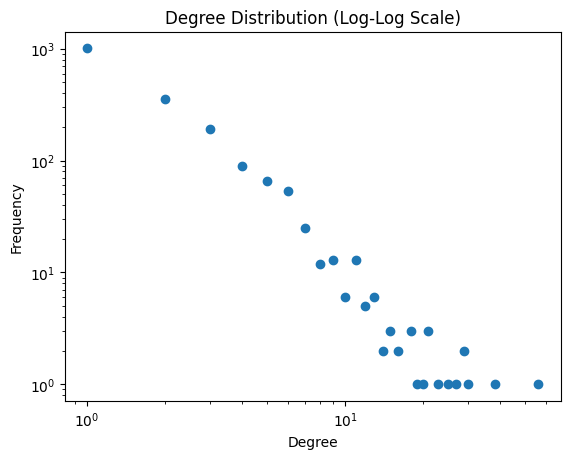

bio, bio-grid-plant
Successfully downloaded bio-grid-plant network.
Network has 2 nodes and 1 edges.
Network is too small to analyze degree distribution.
bio, bio-CE-HT
Successfully downloaded bio-CE-HT network.
Network has 2617 nodes and 2985 edges.


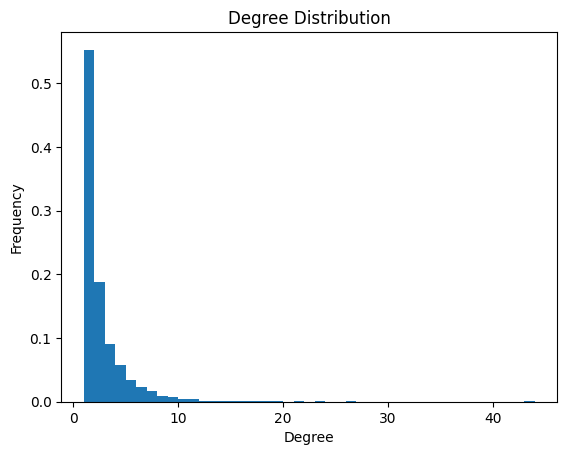

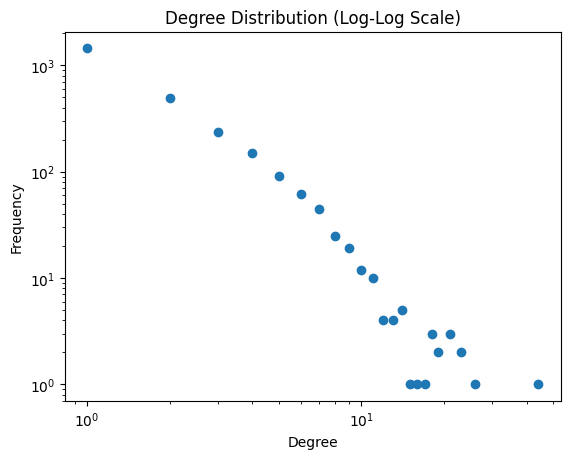

bio, bio-SC-TS
Successfully downloaded bio-SC-TS network.
Network has 636 nodes and 3959 edges.


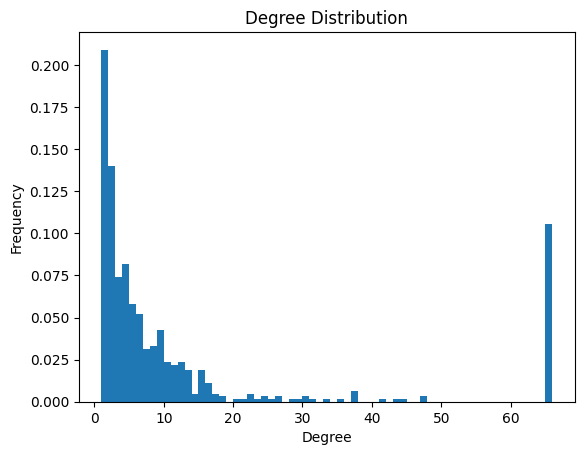

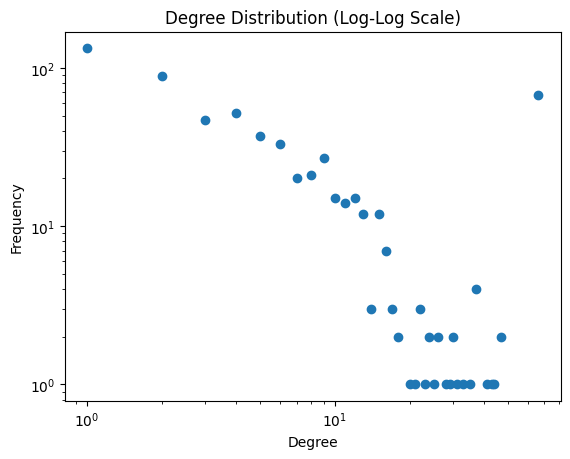

bio, bio-CE-GT
Successfully downloaded bio-CE-GT network.
Network has 924 nodes and 3239 edges.


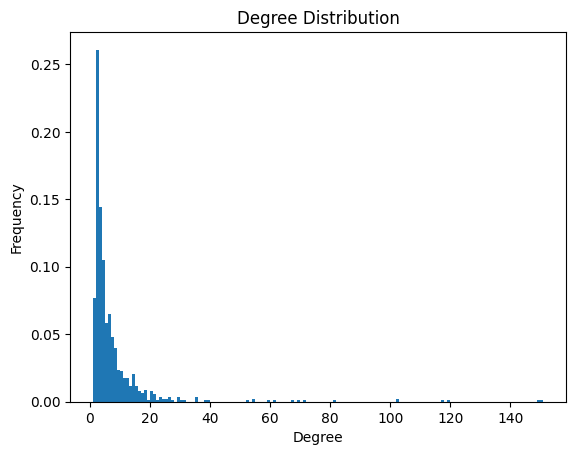

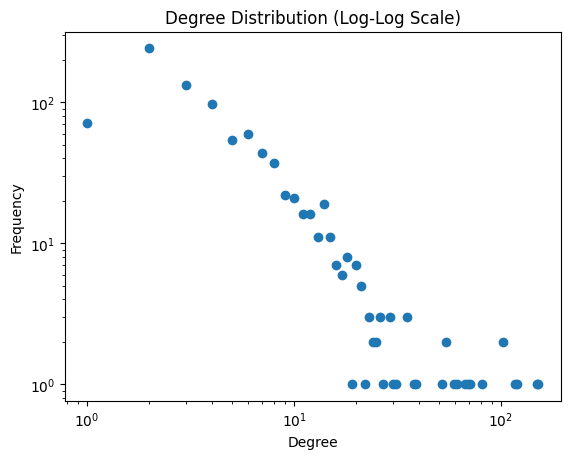

bio, bio-grid-worm
Successfully downloaded bio-grid-worm network.
Network has 2 nodes and 1 edges.
Network is too small to analyze degree distribution.
bio, bio-DM-HT
Successfully downloaded bio-DM-HT network.
Network has 2989 nodes and 4660 edges.


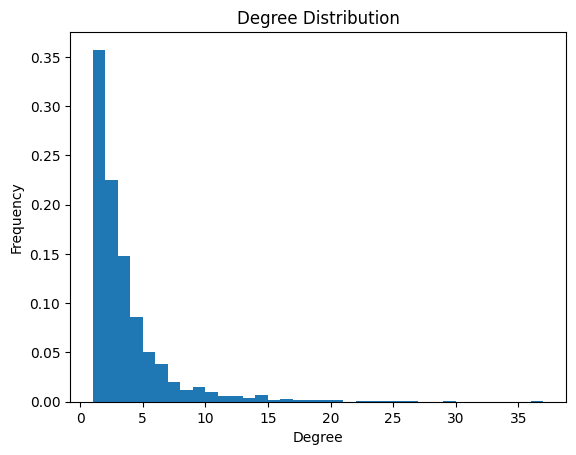

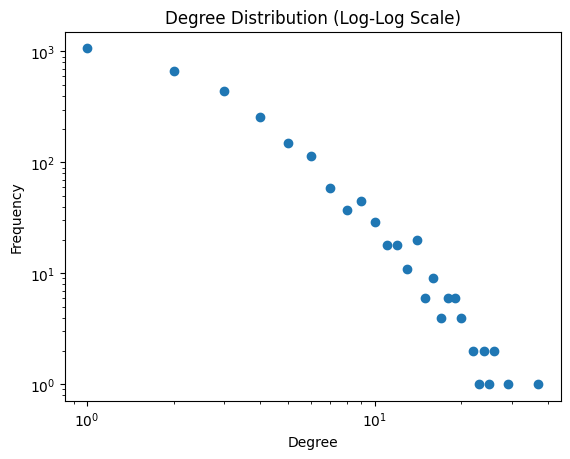

bio, bio-grid-fission-yeast
Successfully downloaded bio-grid-fission-yeast network.
Network has 2 nodes and 1 edges.
Network is too small to analyze degree distribution.
bio, bio-dmela
Successfully downloaded bio-dmela network.
Network has 7395 nodes and 25571 edges.


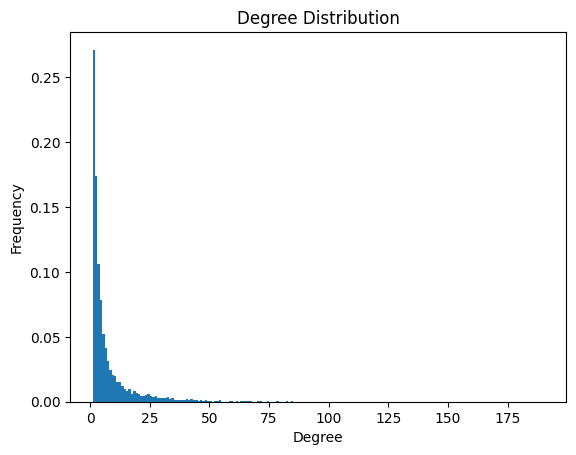

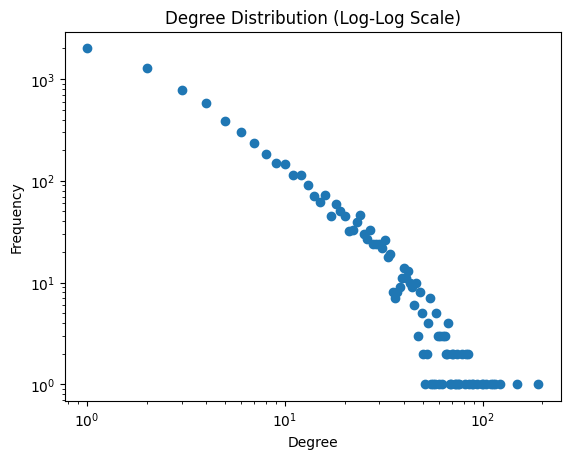

bio, bio-HS-HT
Successfully downloaded bio-HS-HT network.
Network has 2570 nodes and 13691 edges.


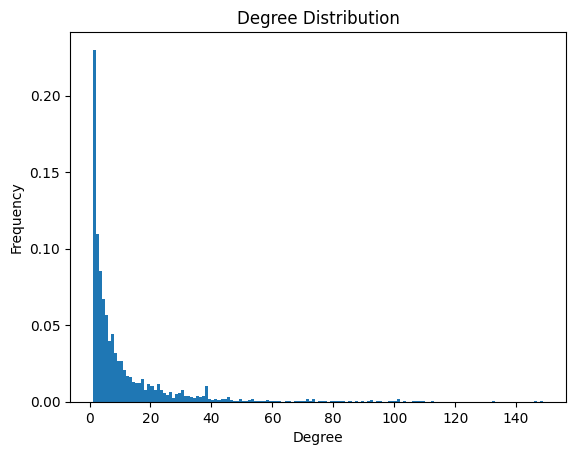

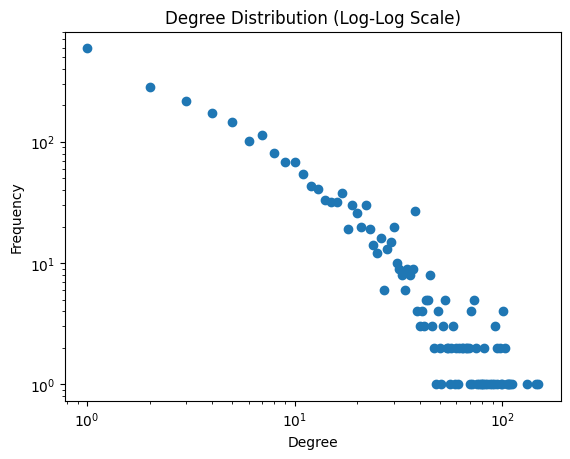

bio, bio-grid-fruitfly
Successfully downloaded bio-grid-fruitfly network.
Network has 2 nodes and 1 edges.
Network is too small to analyze degree distribution.
bio, bio-SC-LC
Successfully downloaded bio-SC-LC network.
Network has 2004 nodes and 20452 edges.


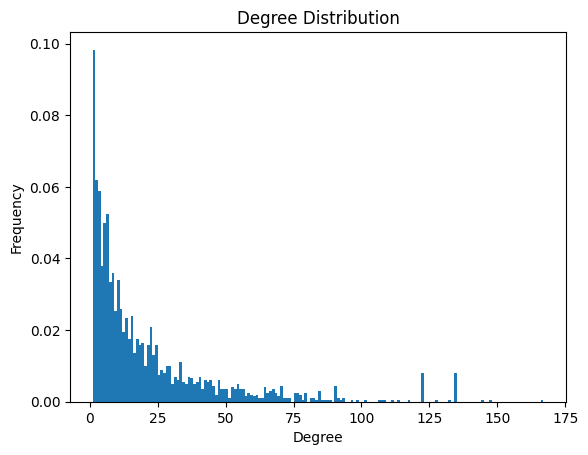

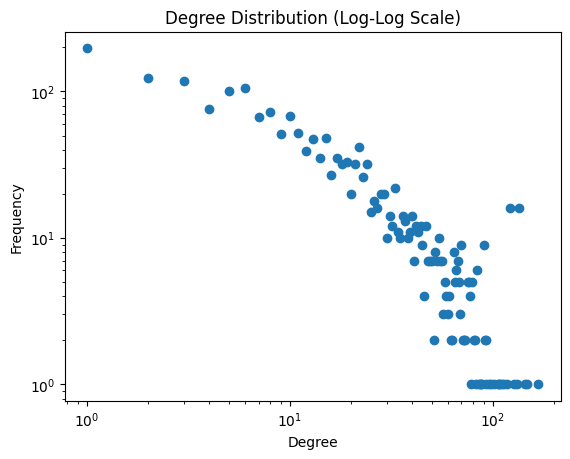

bio, bio-WormNet-v3-benchmark
Successfully downloaded bio-WormNet-v3-benchmark network.
Network has 2445 nodes and 78736 edges.


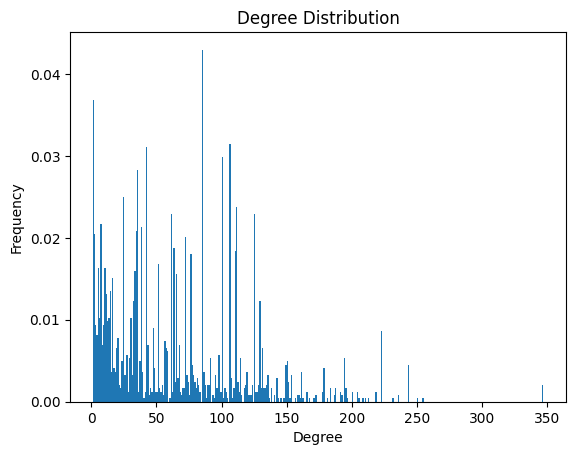

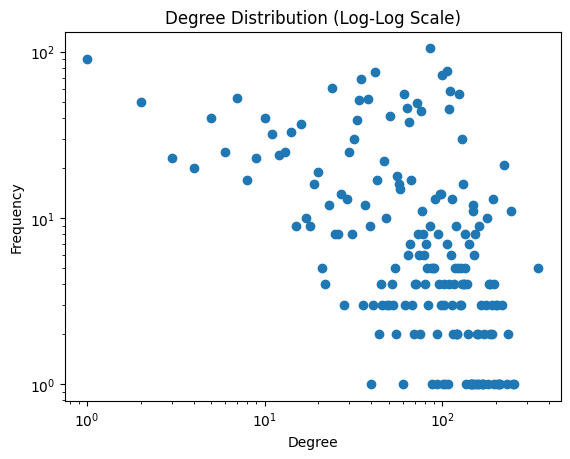

bio, bio-grid-human
Successfully downloaded bio-grid-human network.
Network has 2 nodes and 1 edges.
Network is too small to analyze degree distribution.
bio, bio-SC-CC
Successfully downloaded bio-SC-CC network.
Network has 2223 nodes and 34879 edges.


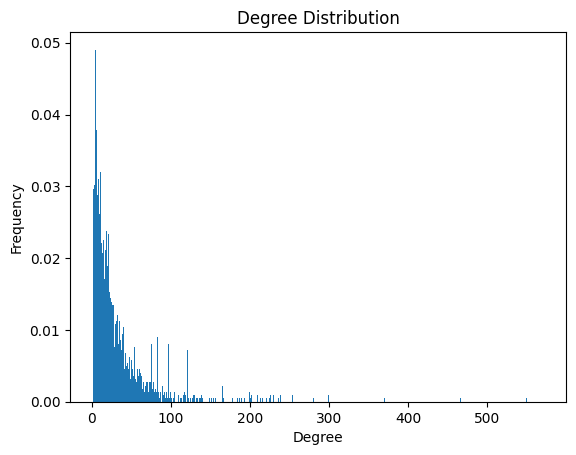

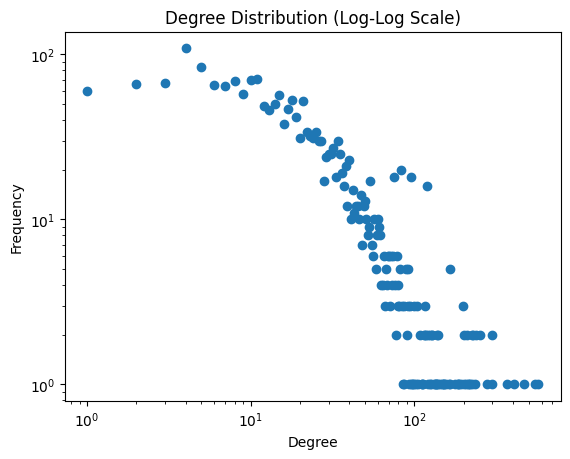

bio, bio-SC-GT
Successfully downloaded bio-SC-GT network.
Network has 1716 nodes and 33987 edges.


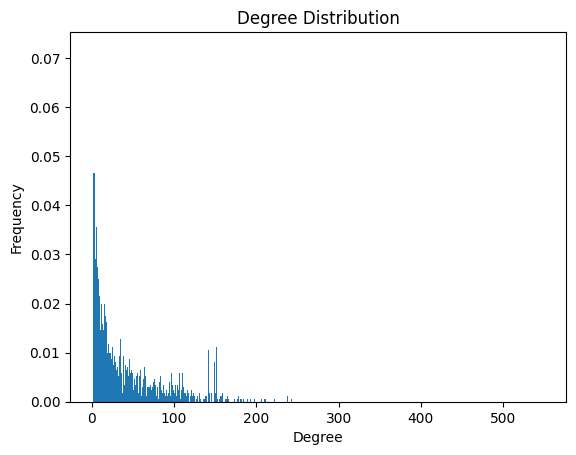

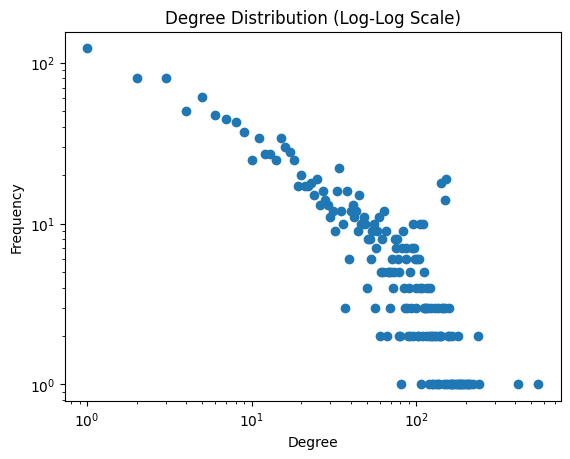

bio, bio-HS-LC
Successfully downloaded bio-HS-LC network.
Network has 4227 nodes and 39484 edges.


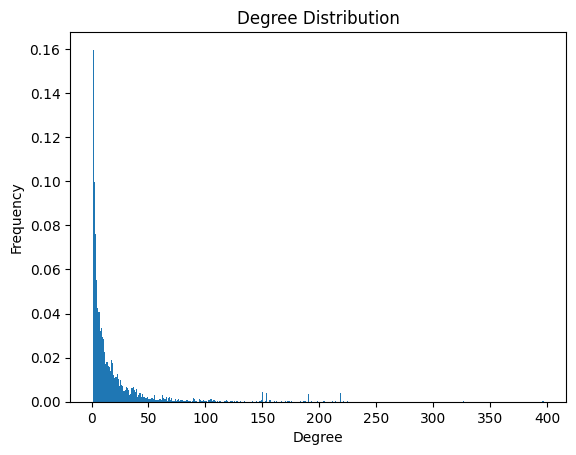

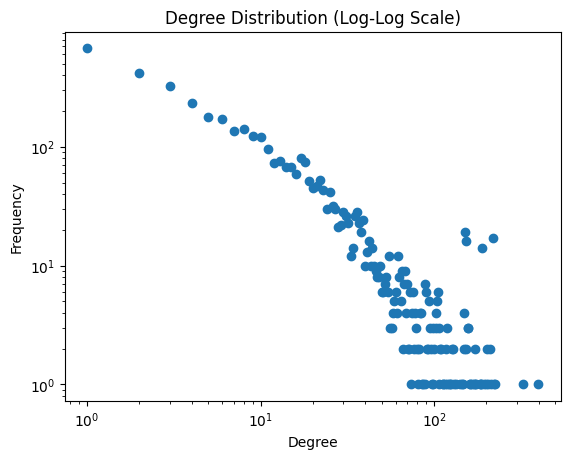

bio, bio-CE-PG
Successfully downloaded bio-CE-PG network.
Network has 1871 nodes and 47754 edges.


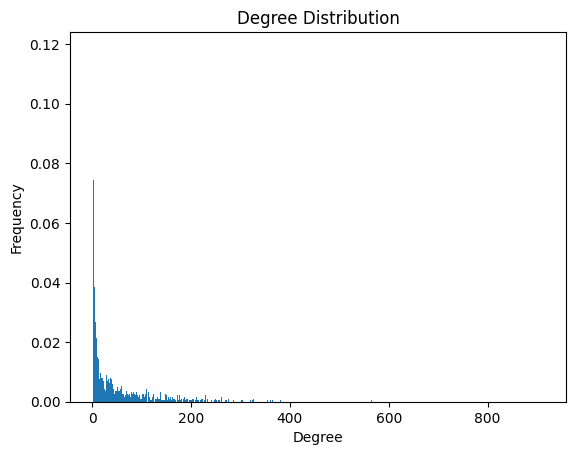

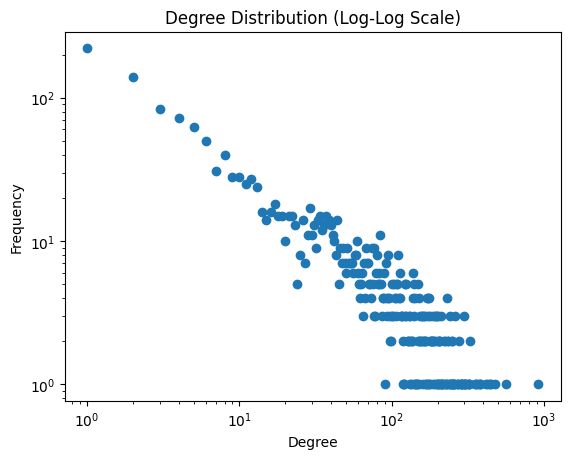

bio, bio-CE-GN
Successfully downloaded bio-CE-GN network.
Network has 2220 nodes and 53683 edges.


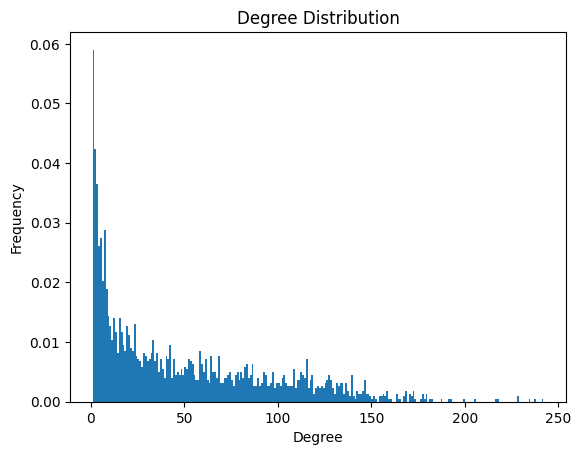

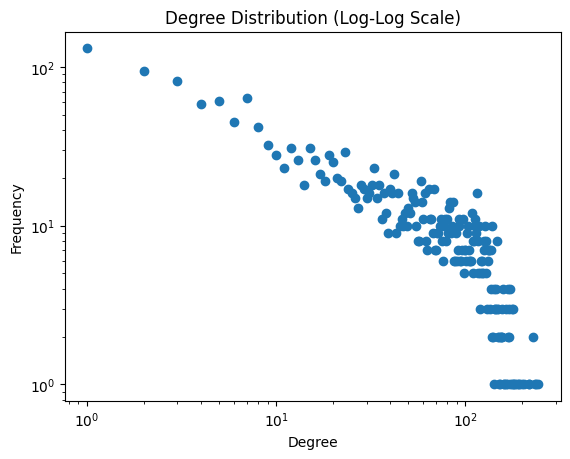

bio, bio-SC-HT
Successfully downloaded bio-SC-HT network.
Network has 2084 nodes and 63027 edges.


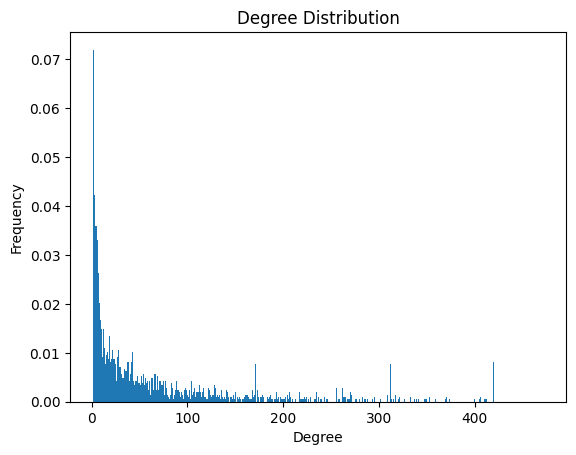

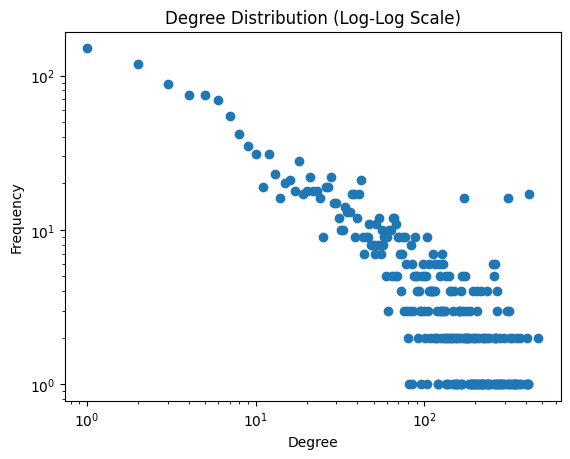

bio, bio-DM-CX
Successfully downloaded bio-DM-CX network.
Network has 4040 nodes and 76717 edges.


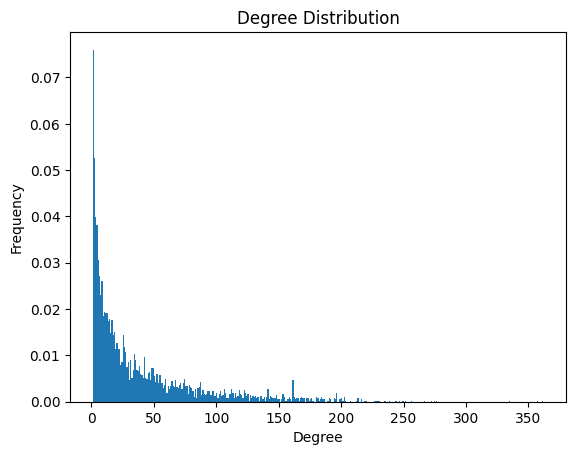

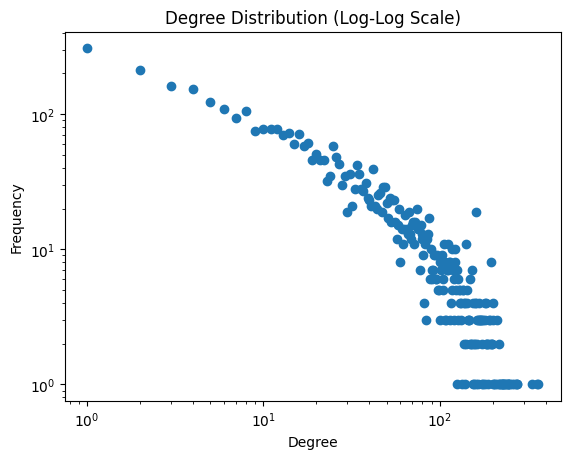

bio, bio-grid-yeast
Successfully downloaded bio-grid-yeast network.
Network has 2 nodes and 1 edges.
Network is too small to analyze degree distribution.
bio, bio-DR-CX
Successfully downloaded bio-DR-CX network.
Network has 3289 nodes and 84940 edges.


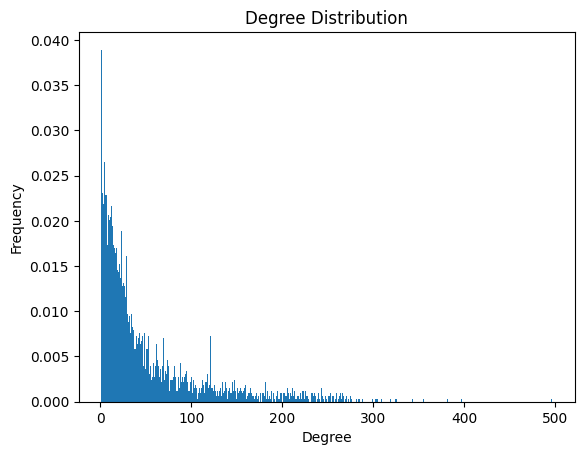

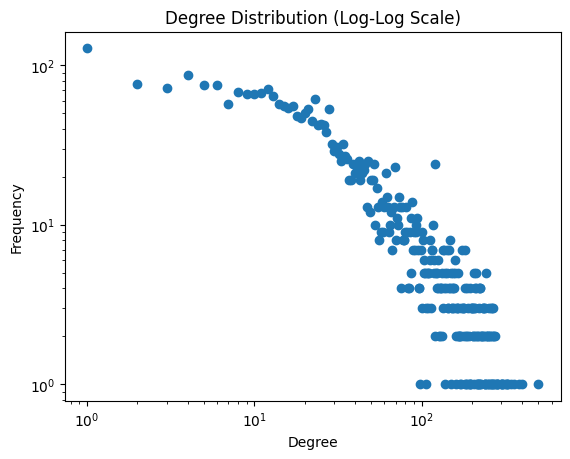

bio, bio-HS-CX
Successfully downloaded bio-HS-CX network.
Network has 4413 nodes and 108818 edges.


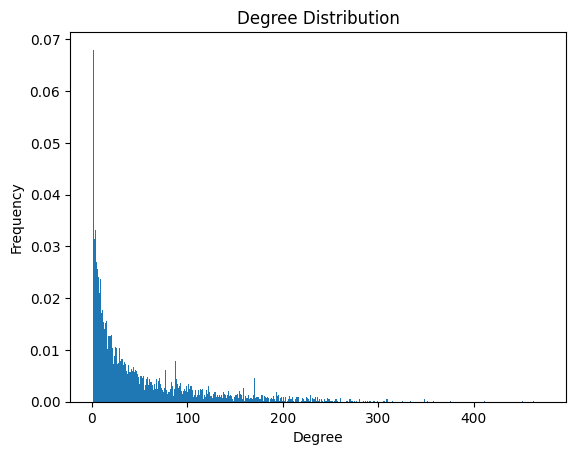

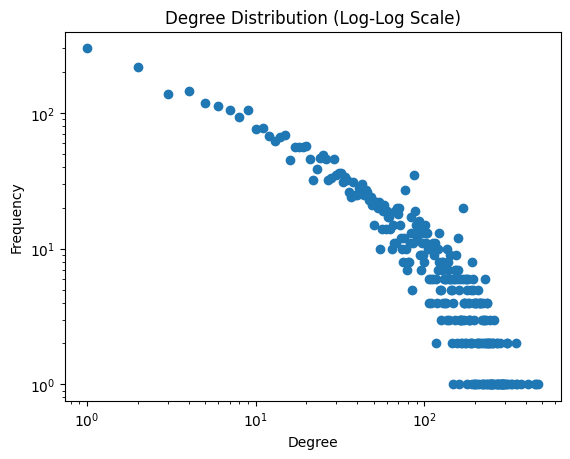

bio, bio-CE-CX
Successfully downloaded bio-CE-CX network.
Network has 15229 nodes and 245952 edges.


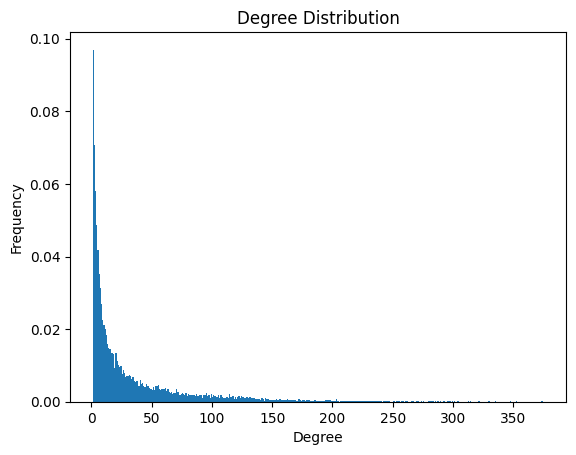

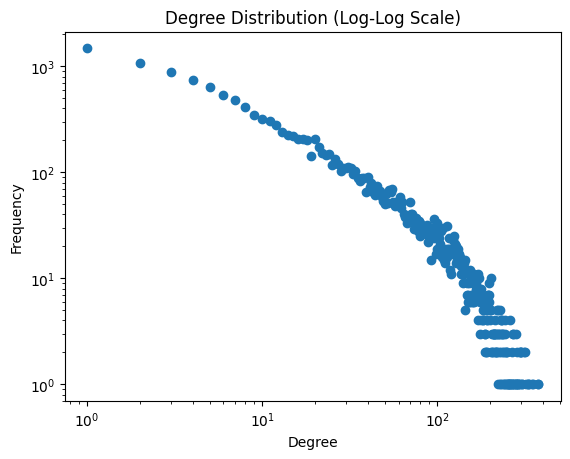

bio, bio-WormNet-v3
Successfully downloaded bio-WormNet-v3 network.
Network has 16347 nodes and 762822 edges.


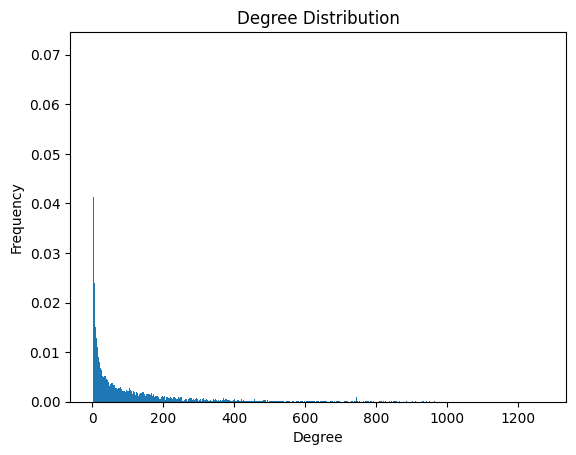

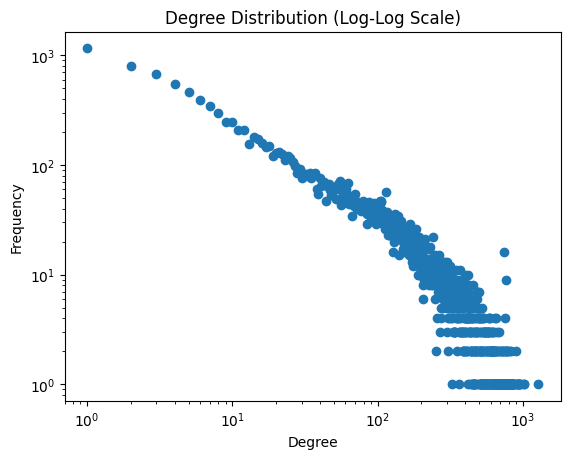

bn, bn-mouse-visual-cortex-1
Failed to download bn-mouse-visual-cortex-1 network. Status code: 404
bn, bn-cat-mixed-species-brain-1
Failed to download bn-cat-mixed-species-brain-1 network. Status code: 404
bn, bn-macaque-rhesus-brain-2
Failed to download bn-macaque-rhesus-brain-2 network. Status code: 404
bn, bn-macaque-rhesus-cerebral-cortex-1
Failed to download bn-macaque-rhesus-cerebral-cortex-1 network. Status code: 404
bn, bn-macaque-rhesus-interrareak0cirticak-network-2
Failed to download bn-macaque-rhesus-interrareak0cirticak-network-2 network. Status code: 404
bn, bn-mouse-visual-cortex-2
Failed to download bn-mouse-visual-cortex-2 network. Status code: 404
bn, bn-mouse-brain-1
Failed to download bn-mouse-brain-1 network. Status code: 404
bn, bn-macaque-rhesus-brain-1
Failed to download bn-macaque-rhesus-brain-1 network. Status code: 404
bn, bn-mouse-kasthuri-graph-v4
Failed to download bn-mouse-kasthuri-graph-v4 network. Status code: 404
bn, bn-mouse-retina-1
Failed to downloa

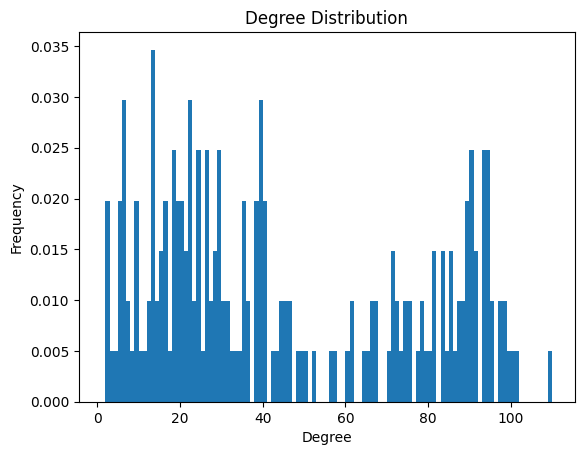

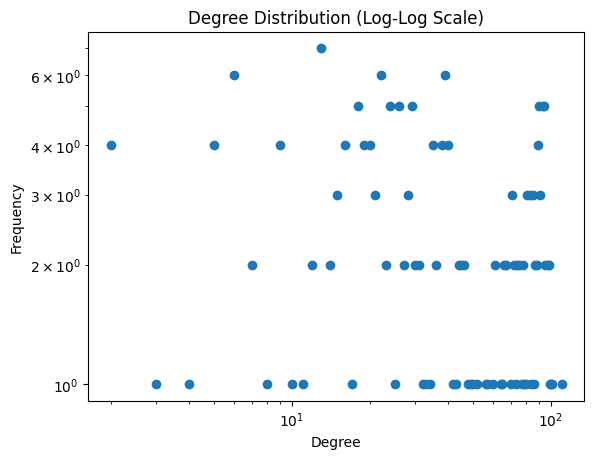

asn, insecta-ant-colony6-day09
Successfully downloaded insecta-ant-colony6-day09 network.
Network has 164 nodes and 10774 edges.


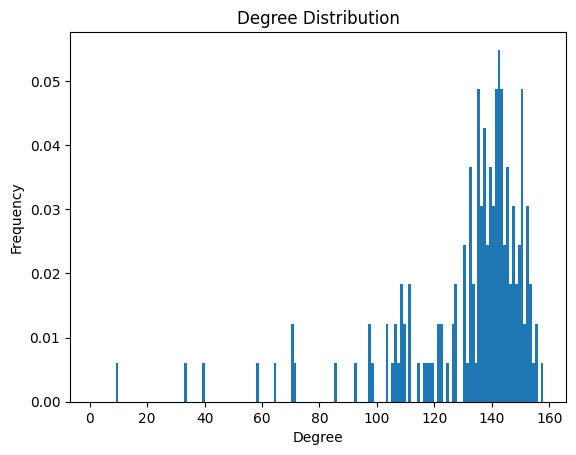

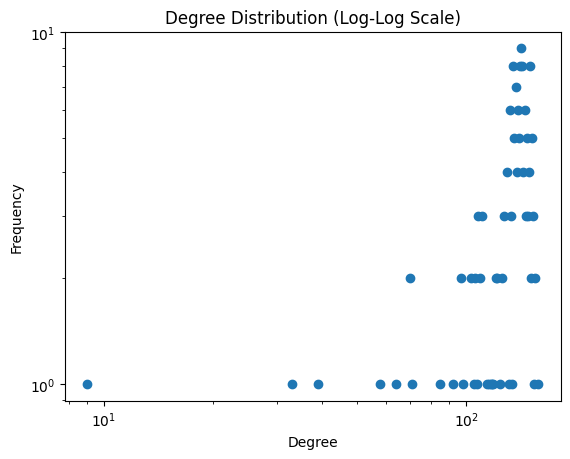

asn, insecta-ant-colony3-day02
Successfully downloaded insecta-ant-colony3-day02 network.
Network has 160 nodes and 9844 edges.


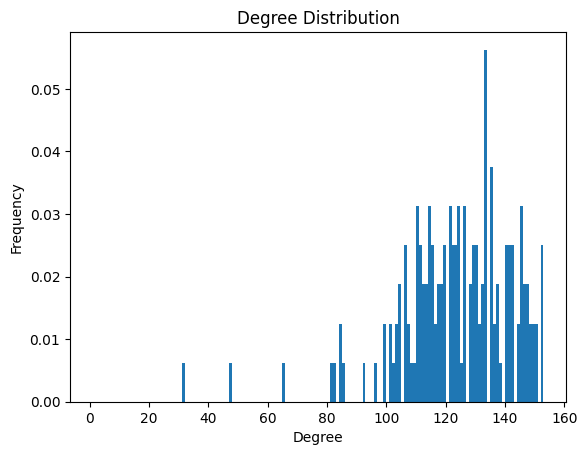

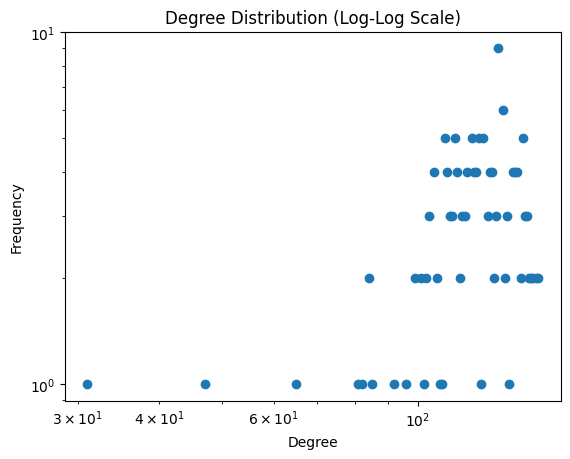

asn, insecta-ant-colony5-day01
Successfully downloaded insecta-ant-colony5-day01 network.
Network has 152 nodes and 9053 edges.


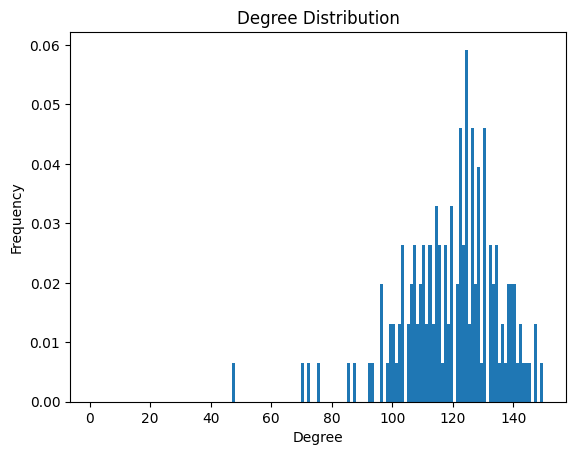

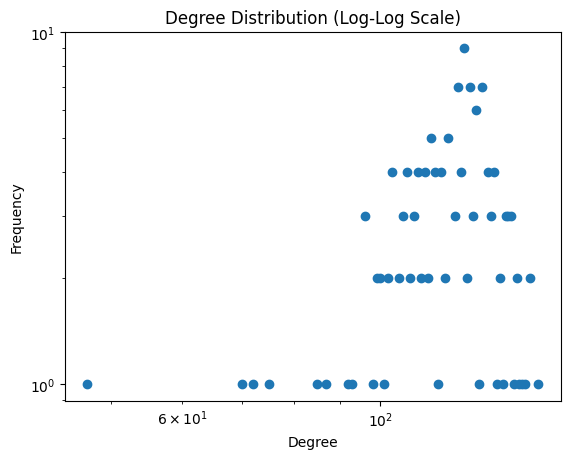

asn, insecta-ant-colony2-day07
Successfully downloaded insecta-ant-colony2-day07 network.
Network has 131 nodes and 6293 edges.


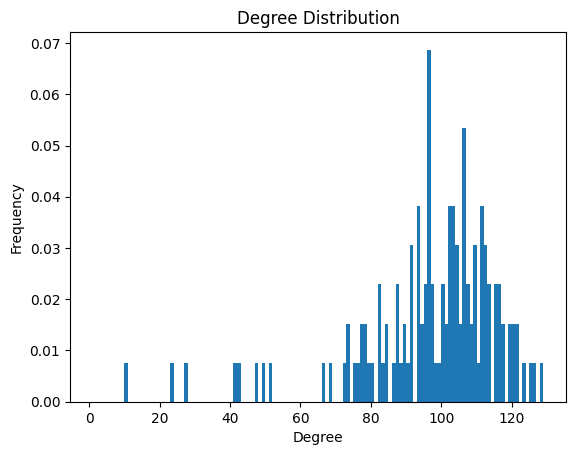

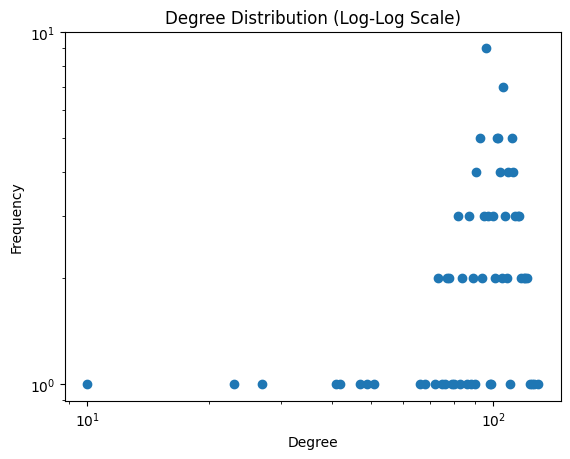

asn, mammalia-voles-bhp-trapping
Successfully downloaded mammalia-voles-bhp-trapping network.
Network has 1686 nodes and 4623 edges.


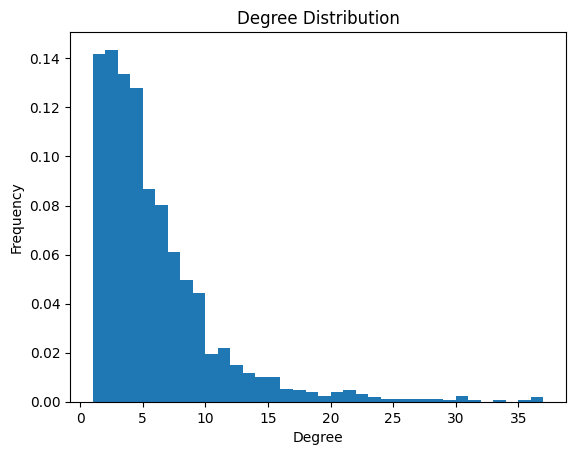

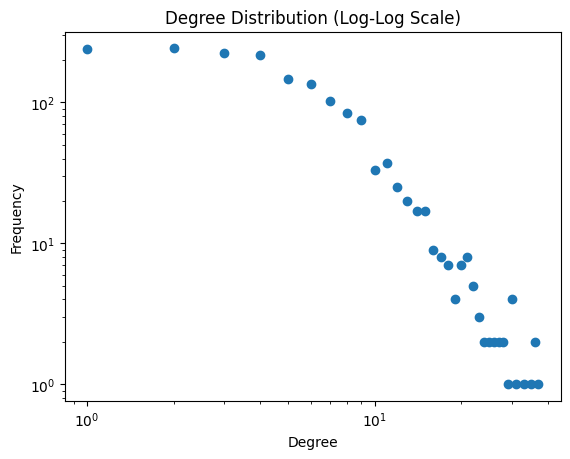

asn, mammalia-voles-rob-trapping
Successfully downloaded mammalia-voles-rob-trapping network.
Network has 1480 nodes and 3935 edges.


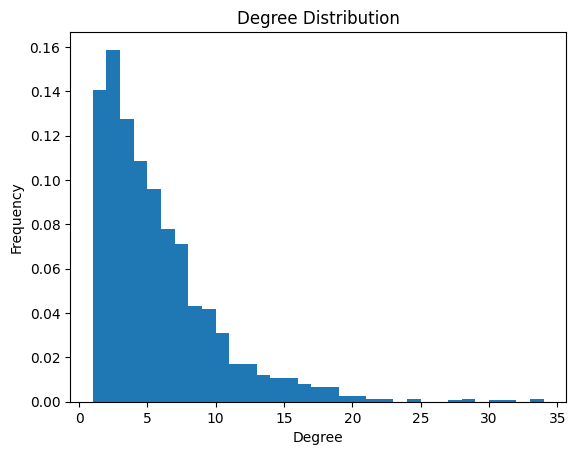

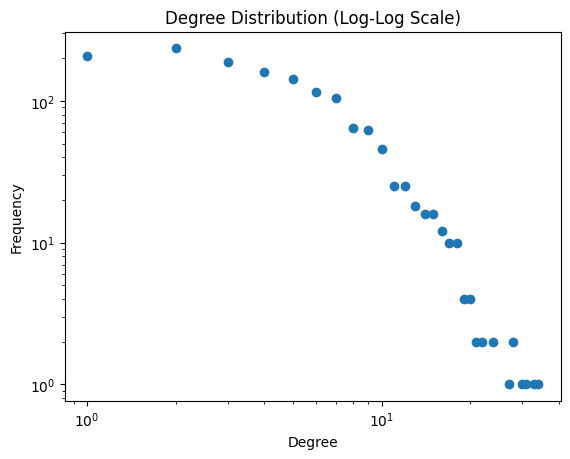

asn, mammalia-voles-kcs-trapping
Successfully downloaded mammalia-voles-kcs-trapping network.
Network has 1218 nodes and 3592 edges.


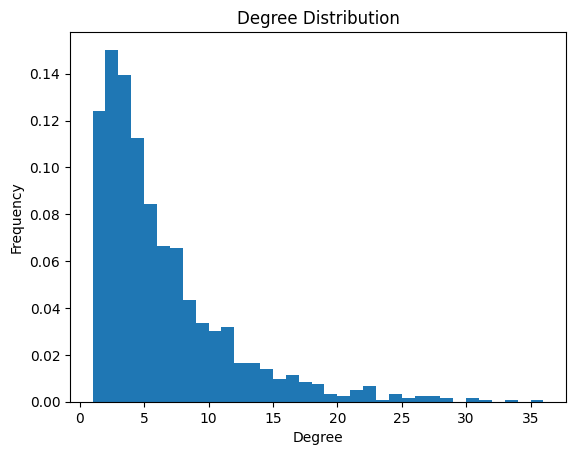

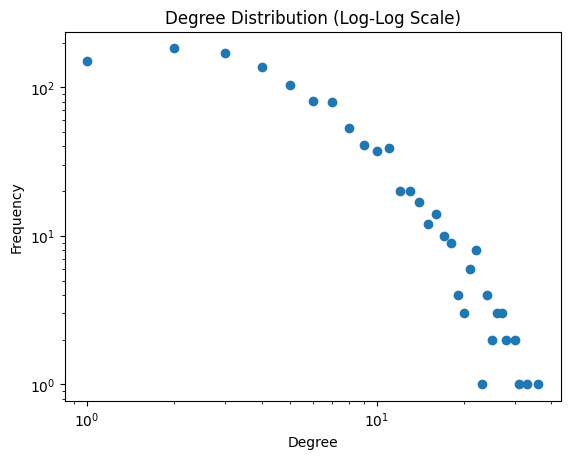

asn, mammalia-voles-pij-trapping
Successfully downloaded mammalia-voles-pij-trapping network.
Could not find the network edges file in the zip for mammalia-voles-pij-trapping.
asn, mammalia-dolphin-florida-overall
Successfully downloaded mammalia-dolphin-florida-overall network.
Network has 291 nodes and 3182 edges.


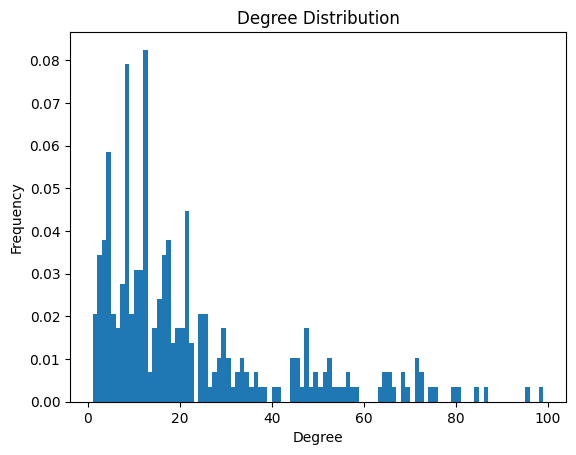

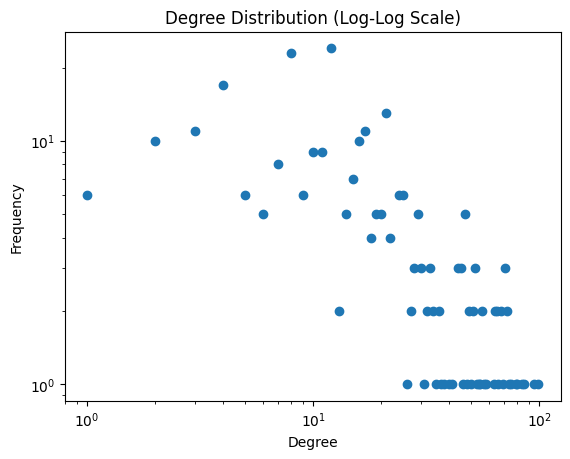

asn, aves-wildbird-network-6
Successfully downloaded aves-wildbird-network-6 network.
Network has 149 nodes and 2837 edges.


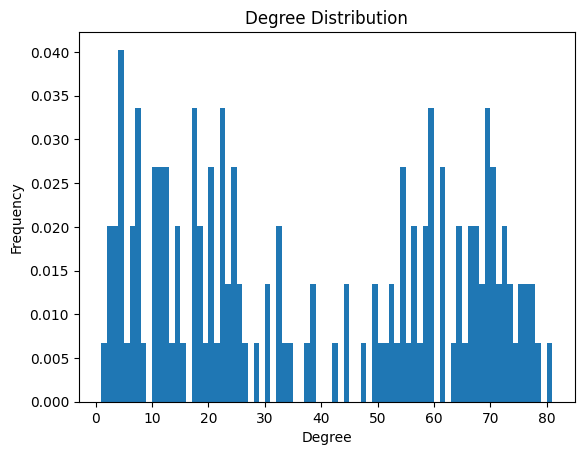

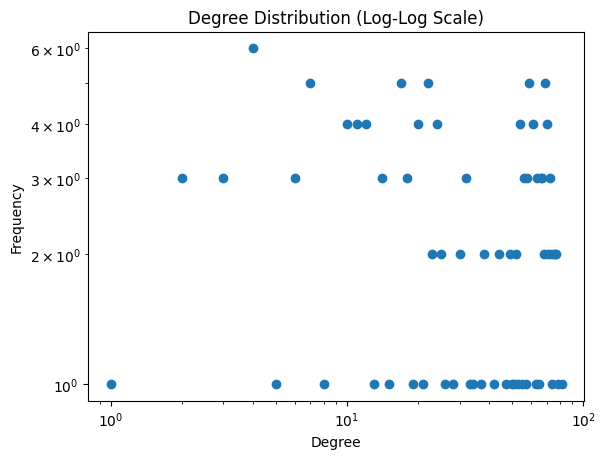

asn, aves-wildbird-network-5
Successfully downloaded aves-wildbird-network-5 network.
Network has 145 nodes and 2512 edges.


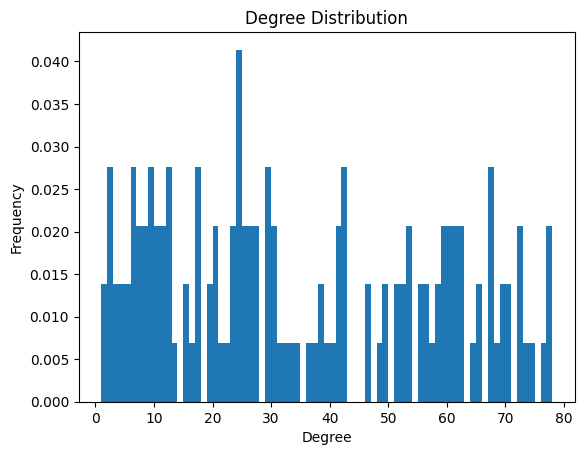

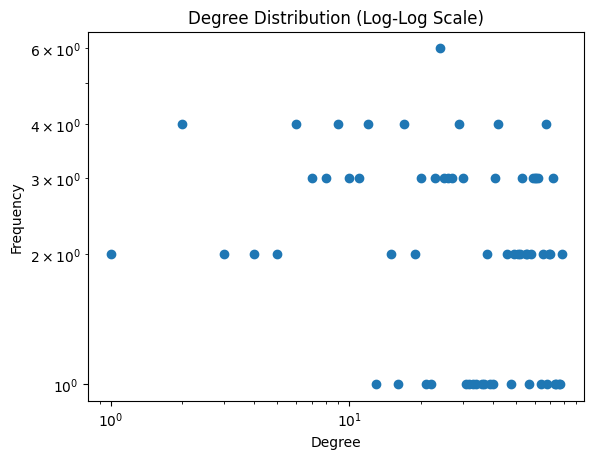

asn, aves-wildbird-network-4
Successfully downloaded aves-wildbird-network-4 network.
Network has 135 nodes and 2009 edges.


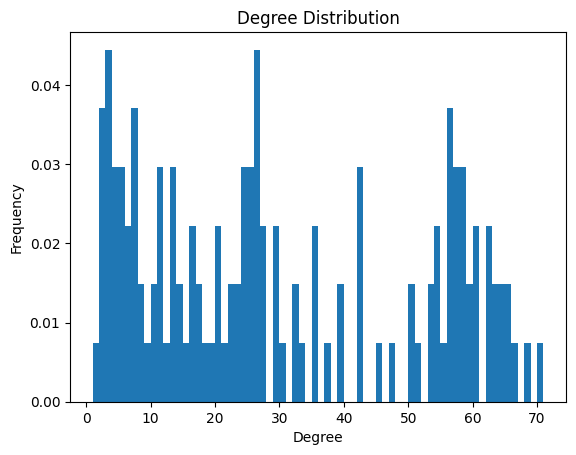

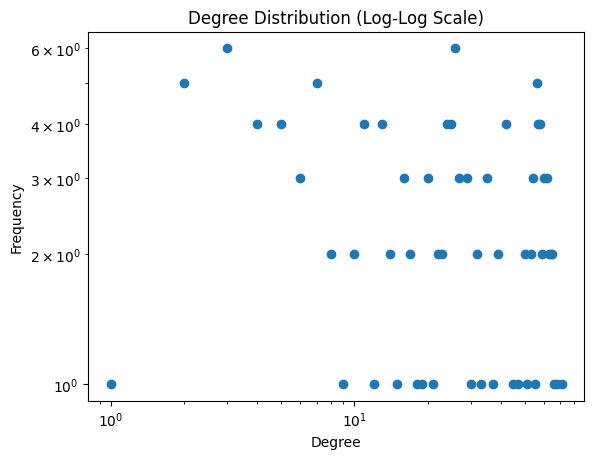

asn, aves-wildbird-network-3
Successfully downloaded aves-wildbird-network-3 network.
Network has 126 nodes and 1615 edges.


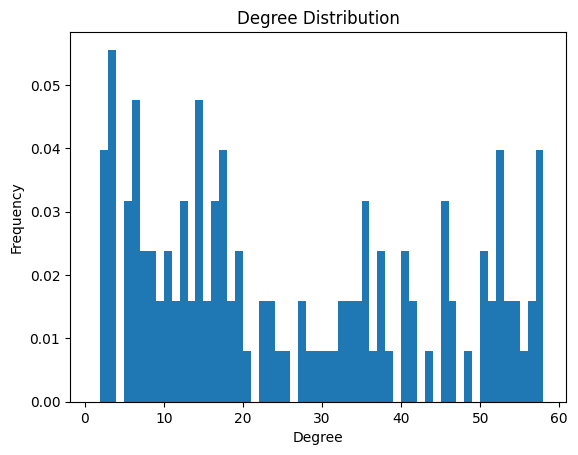

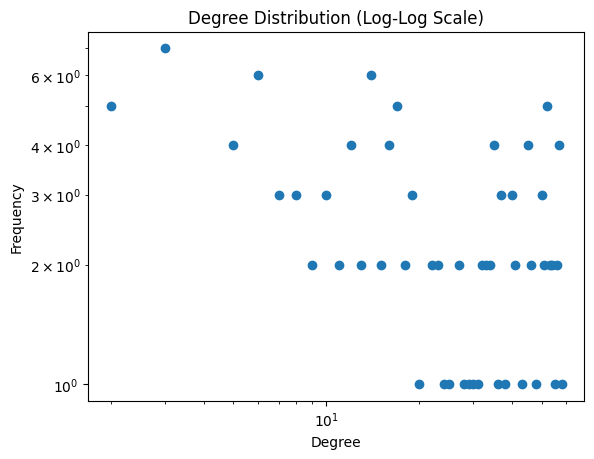

asn, aves-wildbird-network-2
Successfully downloaded aves-wildbird-network-2 network.
Network has 135 nodes and 1483 edges.


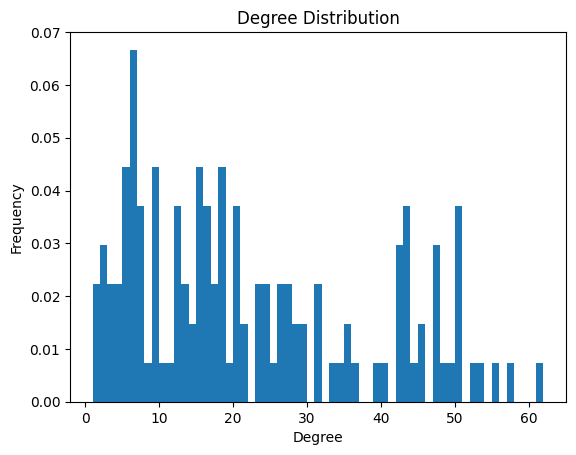

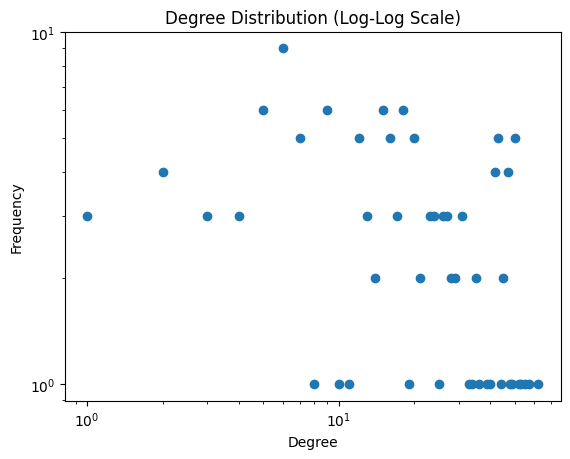

asn, aves-wildbird-network-1
Successfully downloaded aves-wildbird-network-1 network.
Network has 131 nodes and 1444 edges.


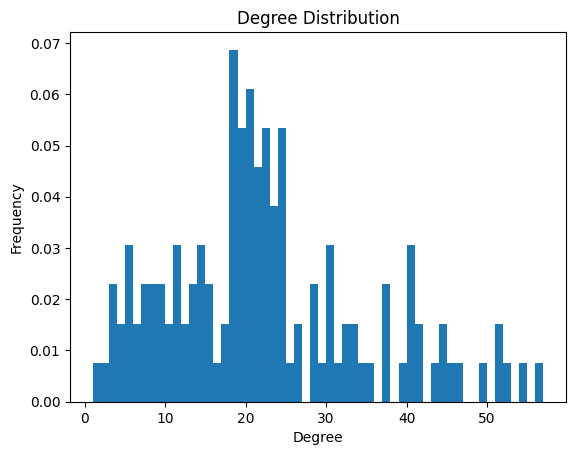

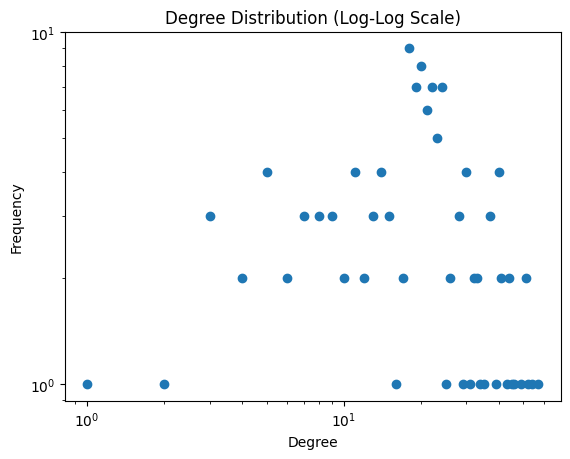

asn, aves-weaver-social
Successfully downloaded aves-weaver-social network.
Network has 445 nodes and 1335 edges.


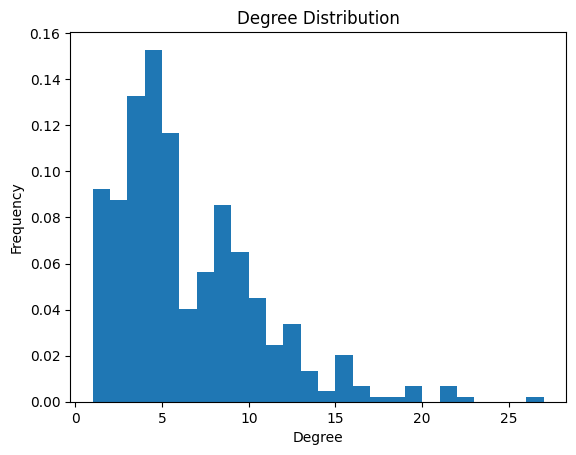

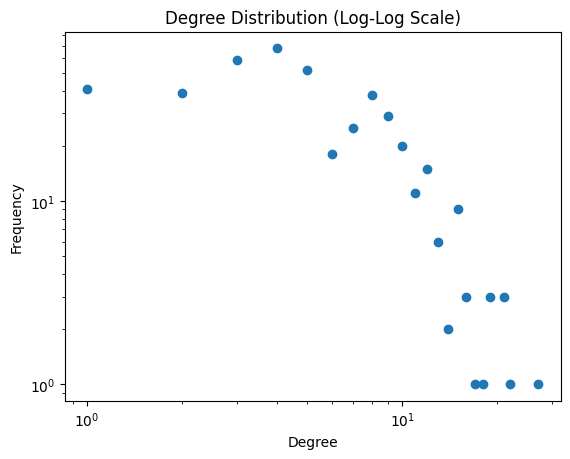

asn, aves-thornbill-farine
Successfully downloaded aves-thornbill-farine network.
Network has 62 nodes and 1151 edges.


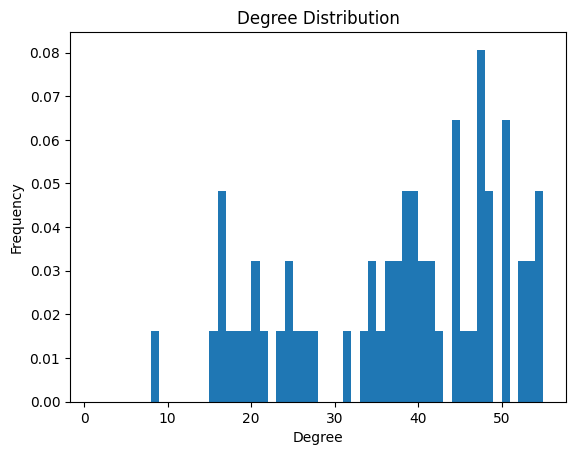

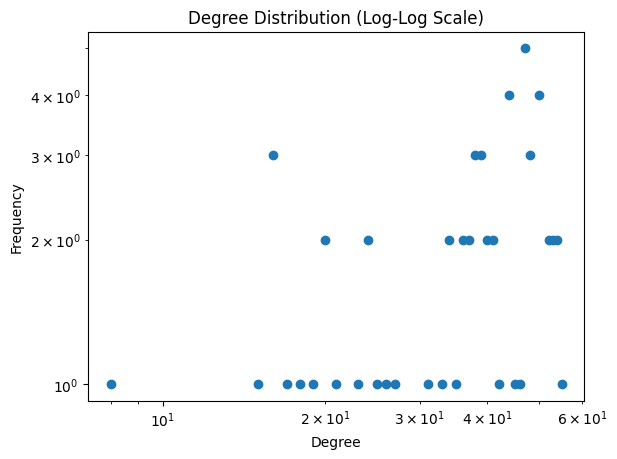

asn, aves-songbird-social
Successfully downloaded aves-songbird-social network.
Network has 110 nodes and 1027 edges.


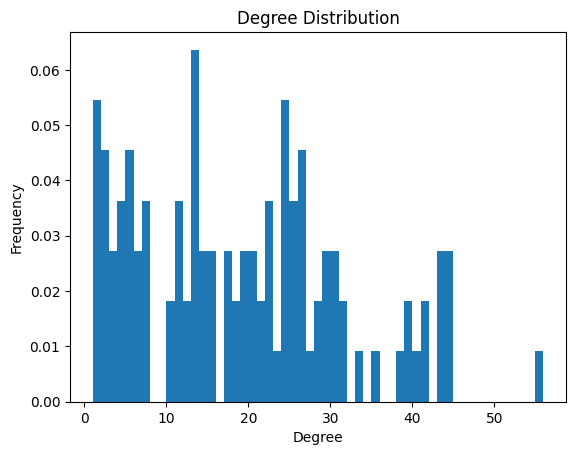

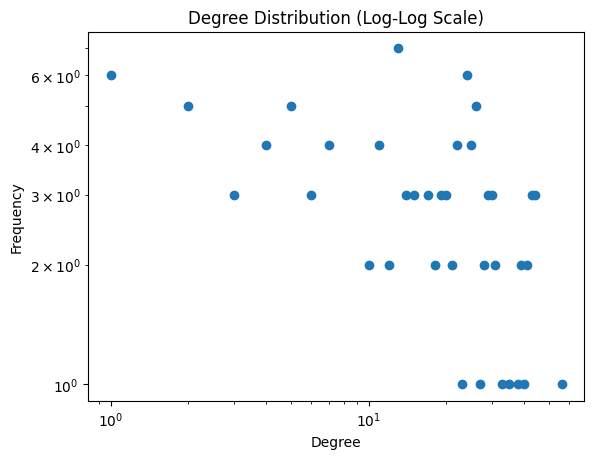

asn, aves-sparrow-social
Successfully downloaded aves-sparrow-social network.
Network has 52 nodes and 454 edges.


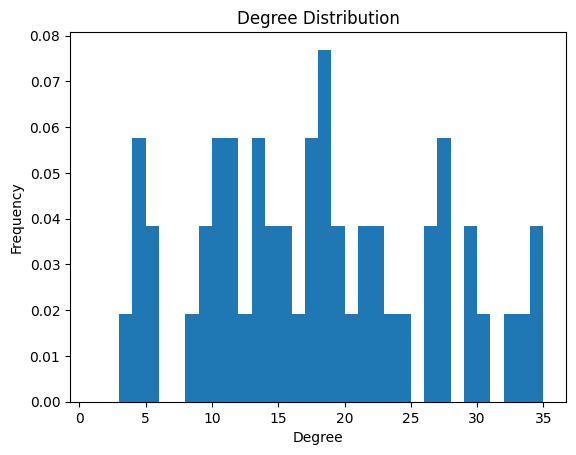

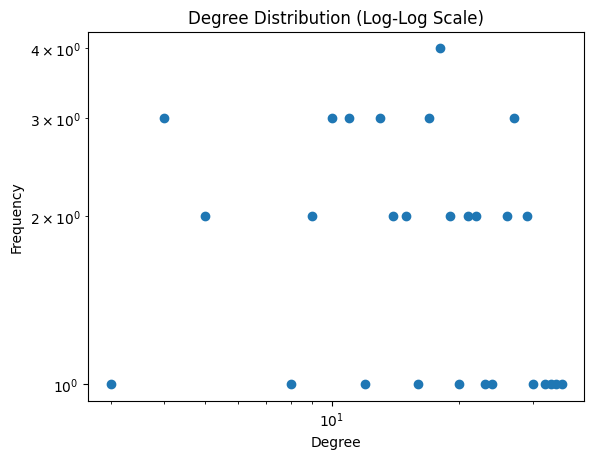

asn, aves-geese-male-foraging
Successfully downloaded aves-geese-male-foraging network.
Network has 23 nodes and 253 edges.


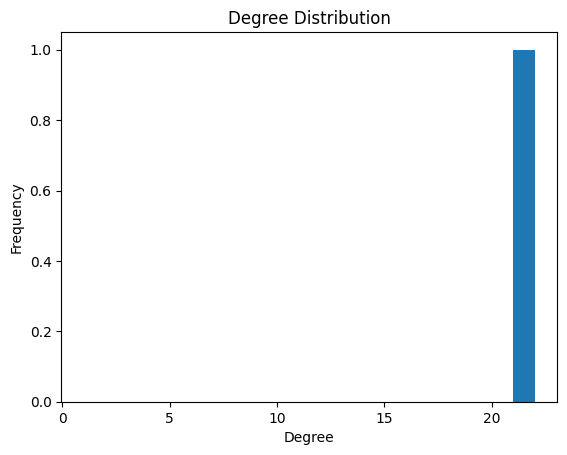

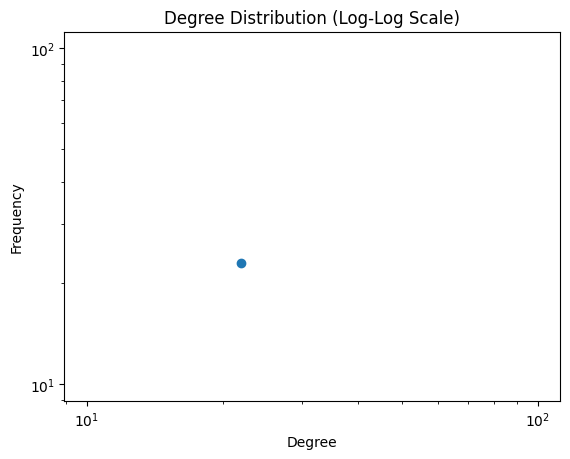

ca, ca-sandi-auths
Successfully downloaded ca-sandi-auths network.
Could not find the network edges file in the zip for ca-sandi-auths.
ca, ca-netscience
Successfully downloaded ca-netscience network.
Network has 382 nodes and 916 edges.


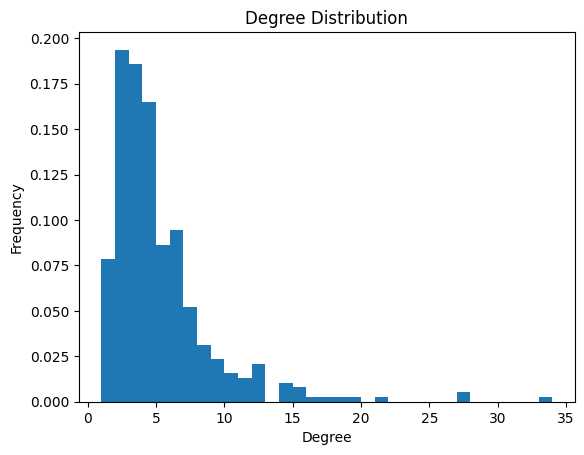

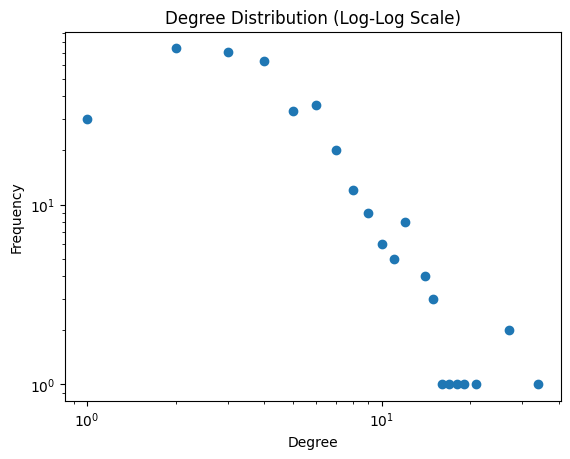

ca, ca-CSphd
Successfully downloaded ca-CSphd network.
Network has 1886 nodes and 1743 edges.


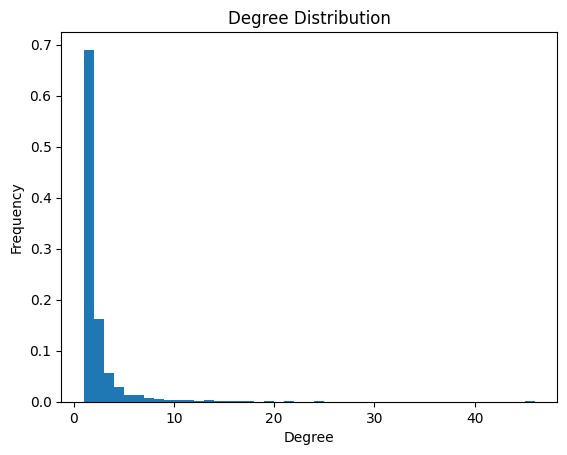

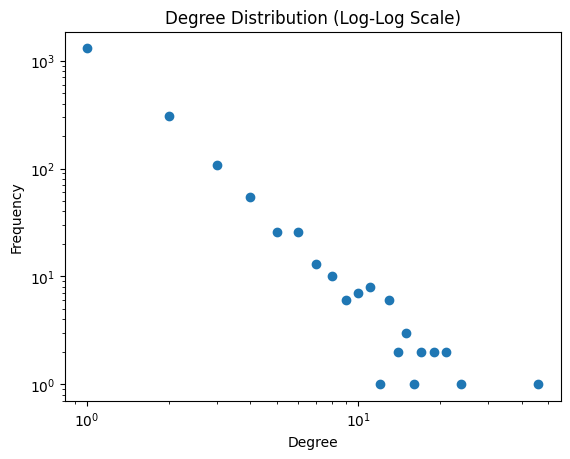

ca, ca-Erdos992
Successfully downloaded ca-Erdos992 network.
Network has 5098 nodes and 7518 edges.


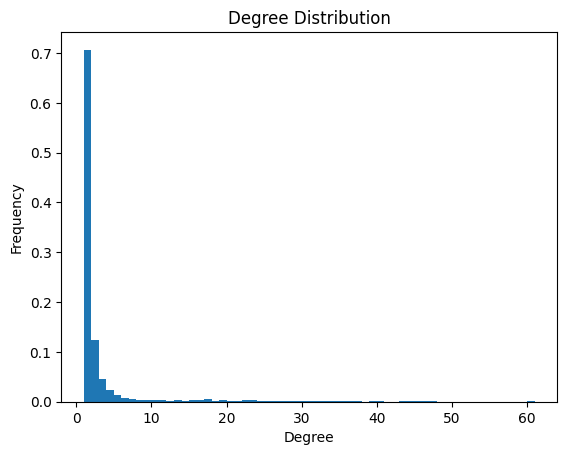

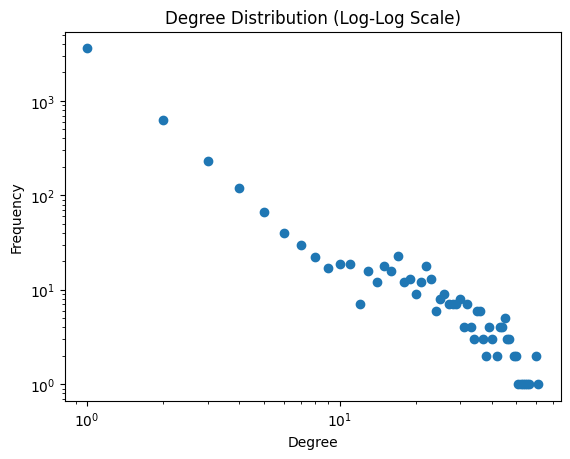

ca, ca-GrQc
Successfully downloaded ca-GrQc network.
Network has 4160 nodes and 13424 edges.


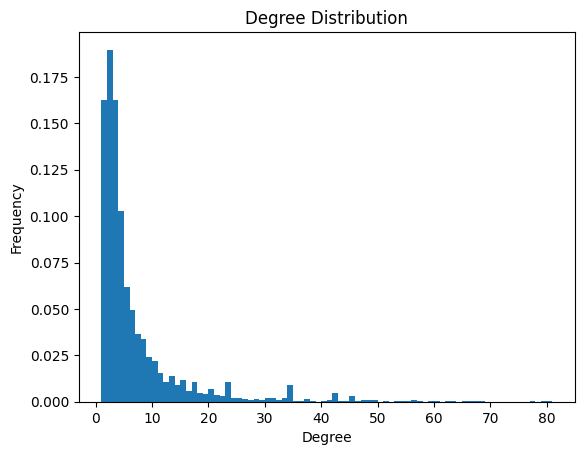

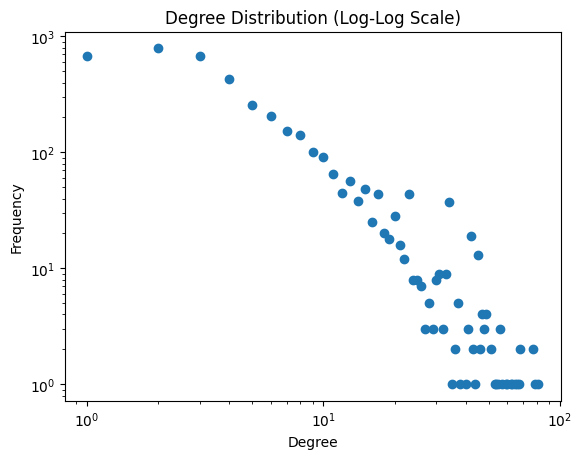

ca, ca-CondMat
Successfully downloaded ca-CondMat network.
Network has 21365 nodes and 91288 edges.


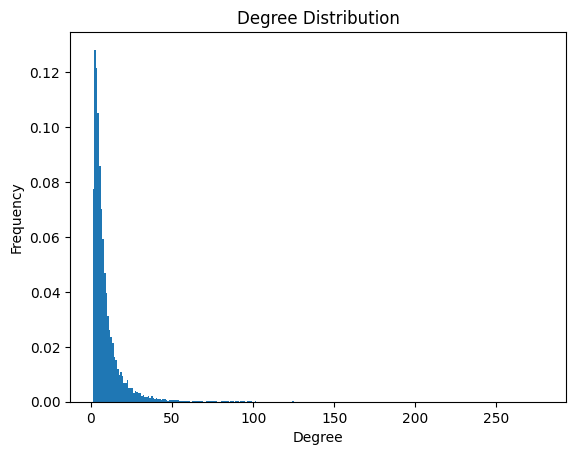

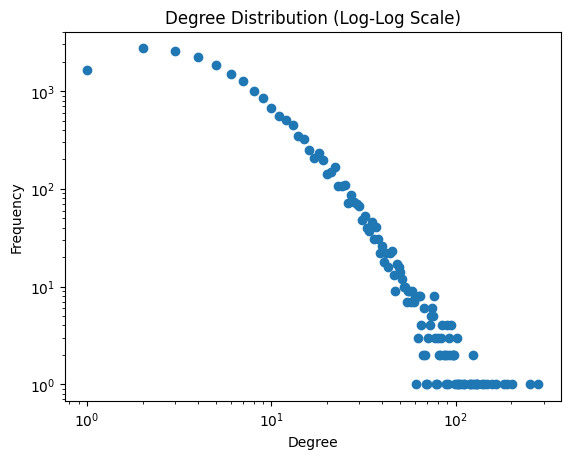

ca, ca-HepPh
Successfully downloaded ca-HepPh network.
Network has 11207 nodes and 117621 edges.


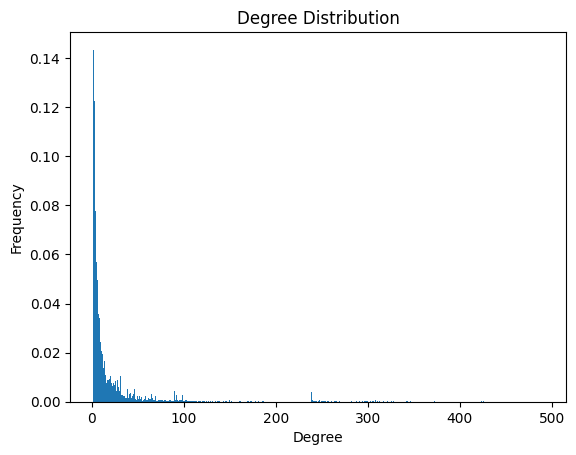

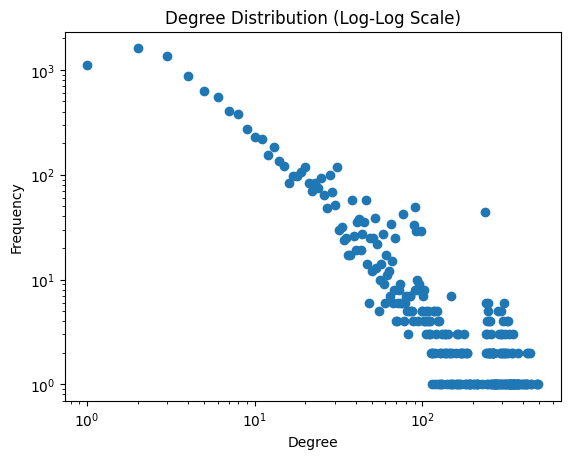

ca, ca-AstroPh
Successfully downloaded ca-AstroPh network.
Network has 17905 nodes and 196974 edges.


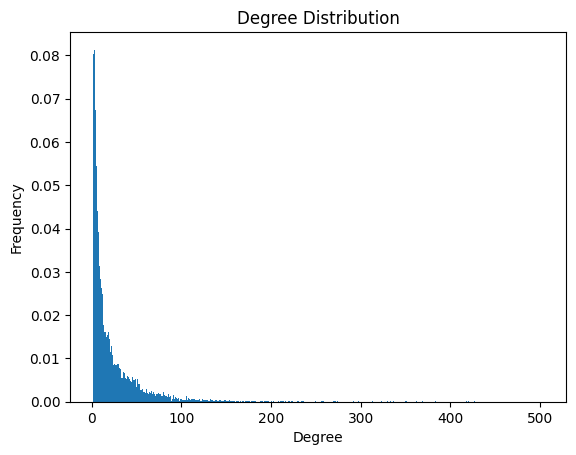

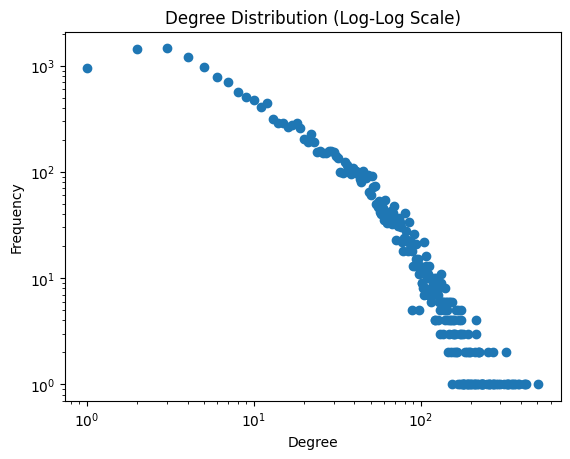

soc, soc-tribes
Successfully downloaded soc-tribes network.
Network has 19 nodes and 60 edges.


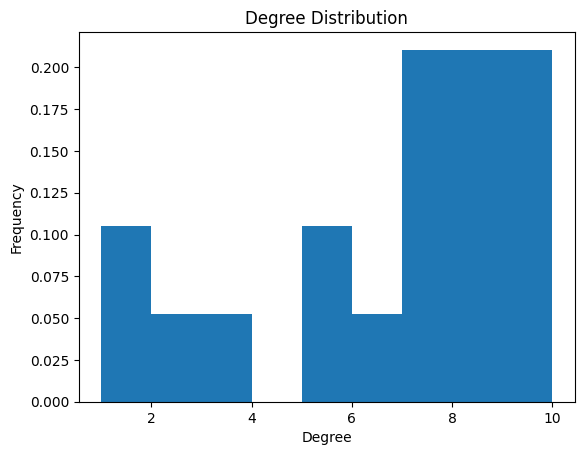

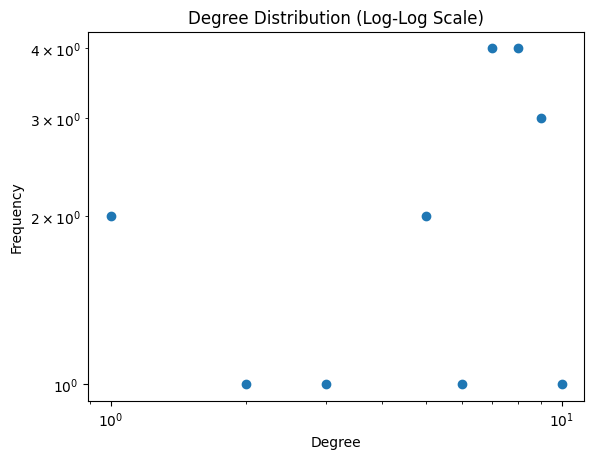

soc, soc-firm-hi-tech
Successfully downloaded soc-firm-hi-tech network.
Network has 33 nodes and 91 edges.


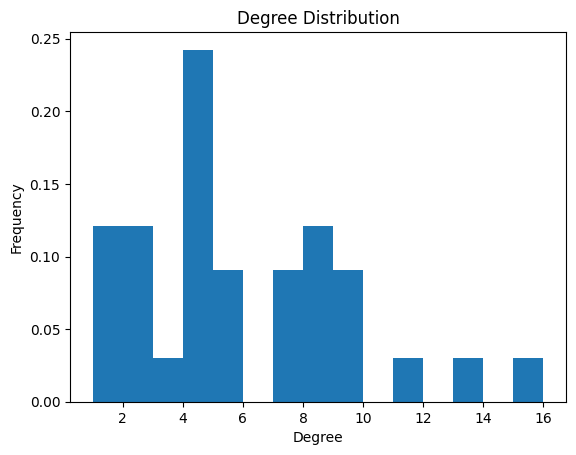

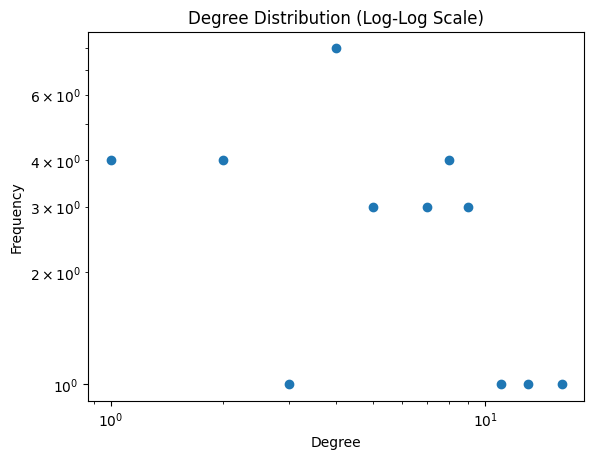

soc, soc-karate
Successfully downloaded soc-karate network.
Network has 55 nodes and 98 edges.


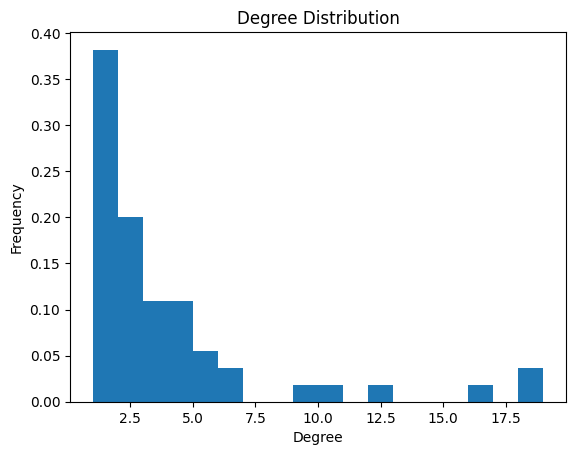

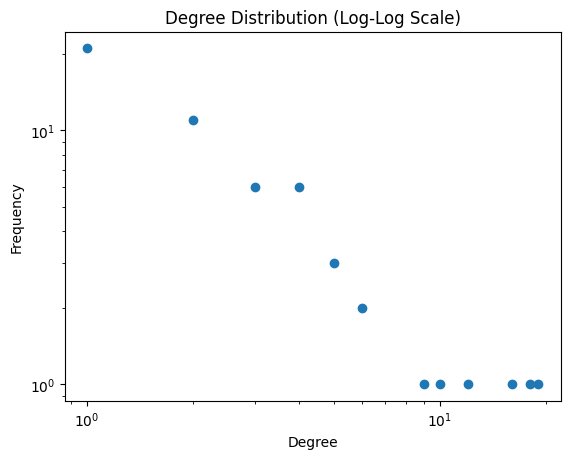

soc, soc-dolphins
Successfully downloaded soc-dolphins network.
Network has 89 nodes and 185 edges.


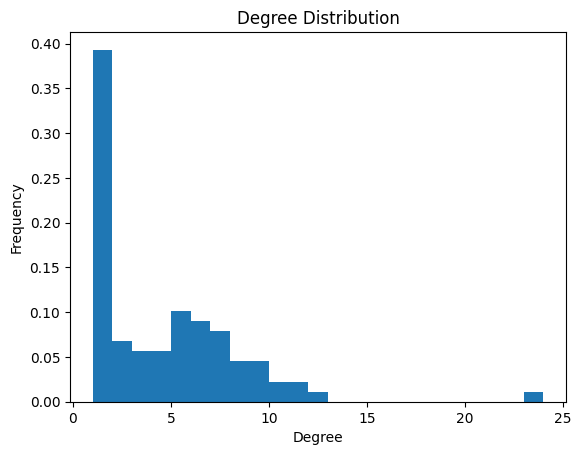

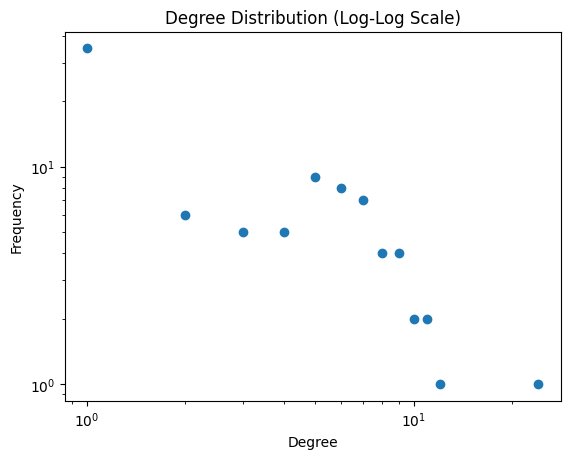

soc, soc-wiki-Vote
Successfully downloaded soc-wiki-Vote network.
Network has 891 nodes and 2916 edges.


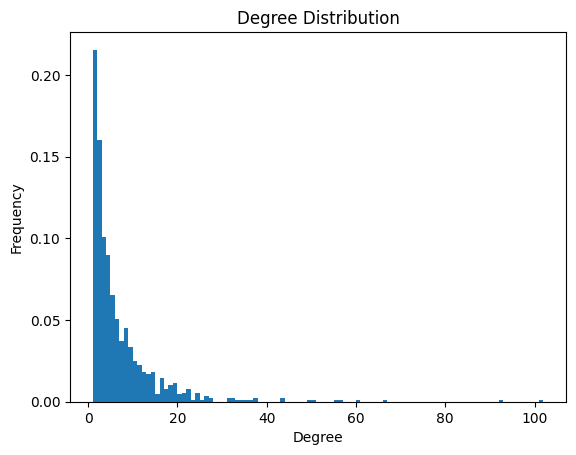

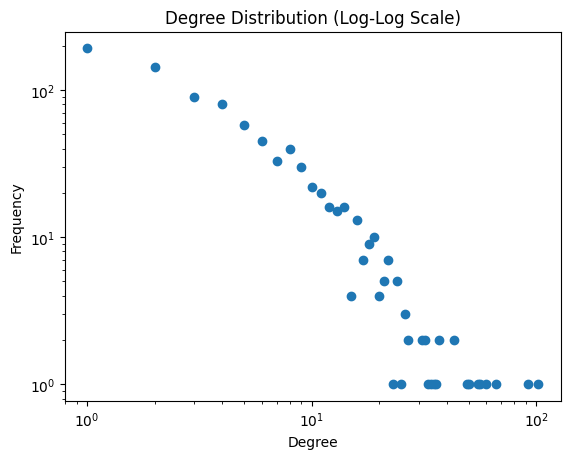

soc, soc-pages-food
Failed to download soc-pages-food network. Status code: 404
soc, soc-hamsterster
Successfully downloaded soc-hamsterster network.
Network has 2429 nodes and 16632 edges.


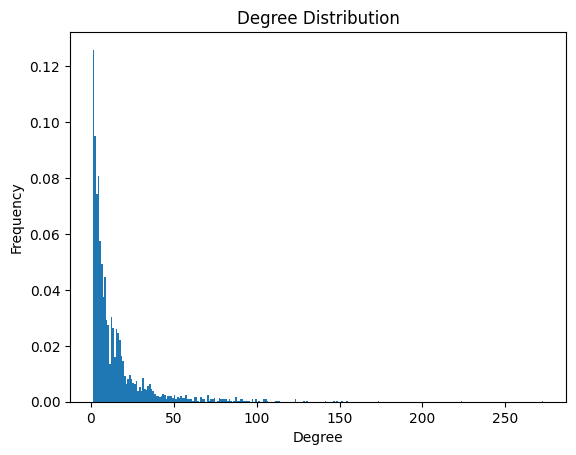

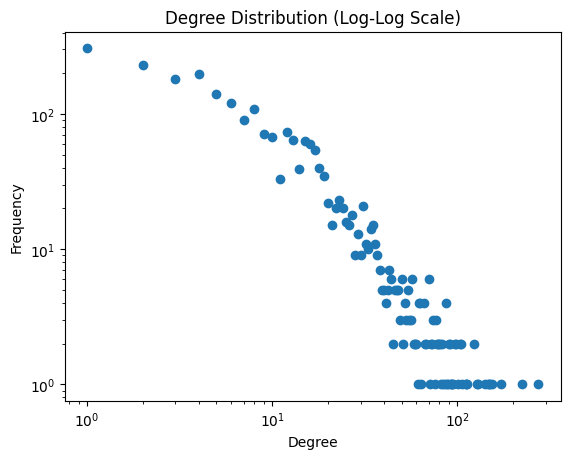

soc, soc-pages-tvshow
Failed to download soc-pages-tvshow network. Status code: 404
soc, soc-advogato
Successfully downloaded soc-advogato network.
Network has 6555 nodes and 43430 edges.


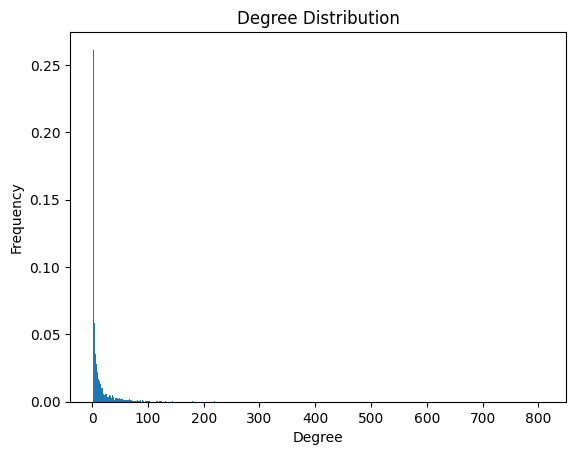

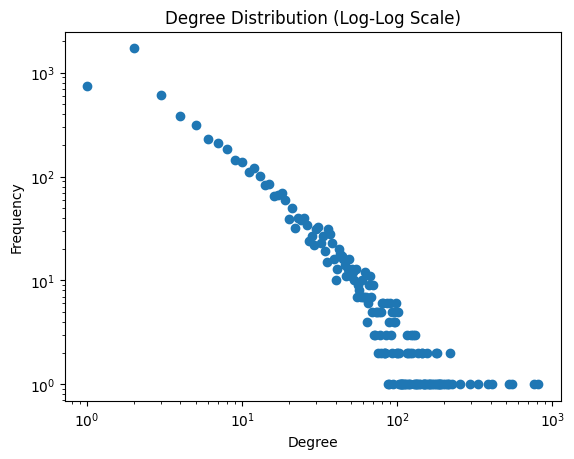

soc, soc-anybeat
Successfully downloaded soc-anybeat network.
Network has 12645 nodes and 49132 edges.


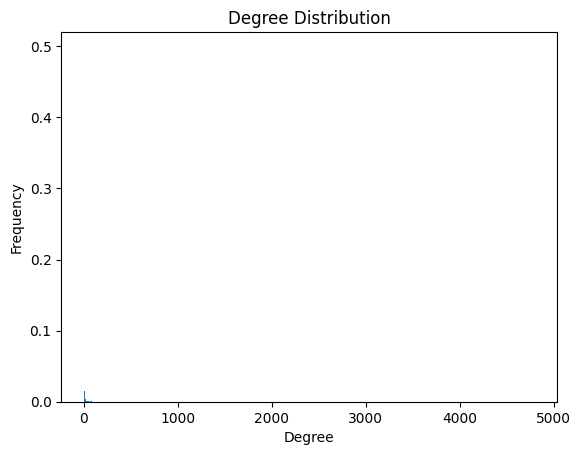

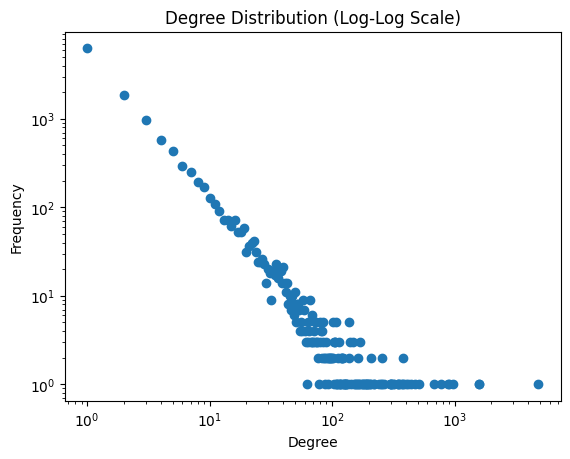

soc, soc-pages-politician
Failed to download soc-pages-politician network. Status code: 404
email, email-enron-only
Successfully downloaded email-enron-only network.
Network has 145 nodes and 625 edges.


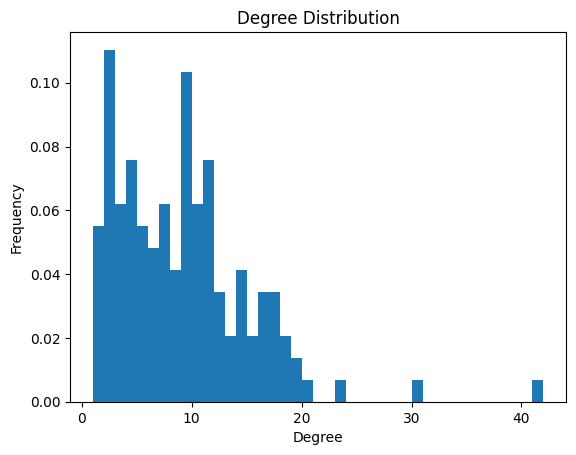

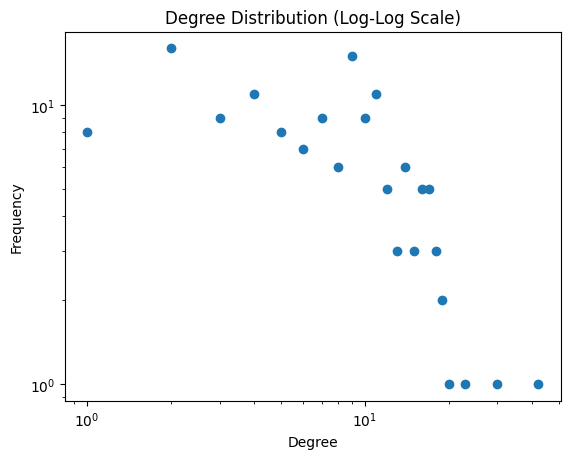

email, email-dnc-corecipient
Successfully downloaded email-dnc-corecipient network.
Network has 908 nodes and 10430 edges.


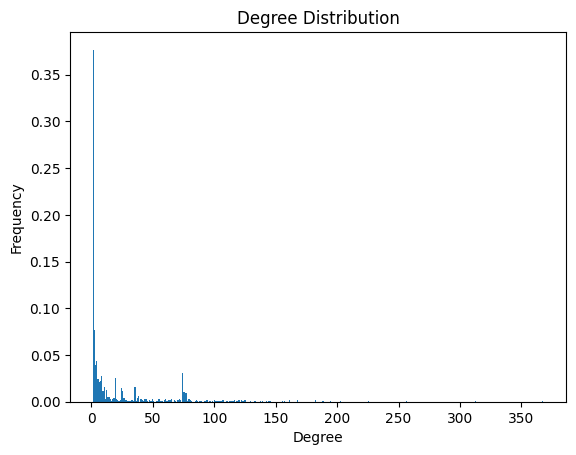

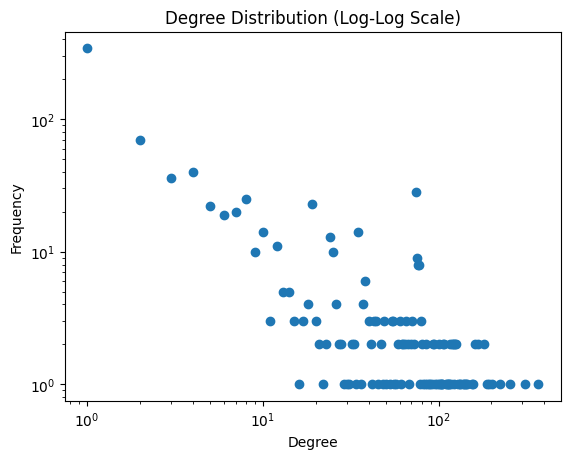

email, email-univ
Successfully downloaded email-univ network.
Network has 1133 nodes and 5451 edges.


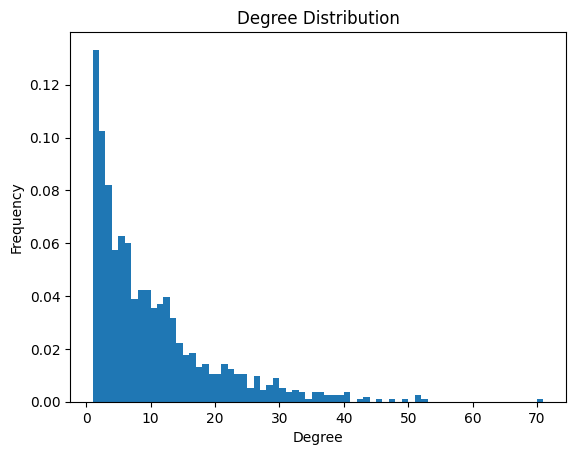

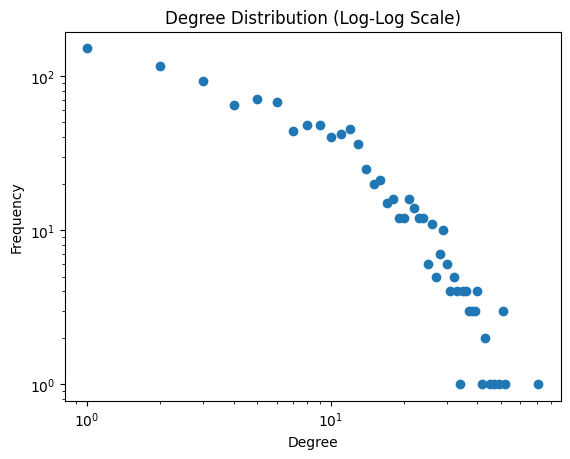

email, email-dnc
Successfully downloaded email-dnc network.
Network has 0 nodes and 0 edges.
Network is too small to analyze degree distribution.
email, email-EU
Successfully downloaded email-EU network.
Network has 32430 nodes and 54397 edges.


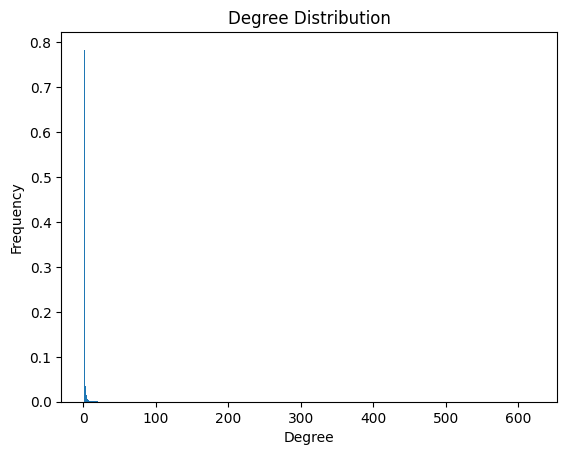

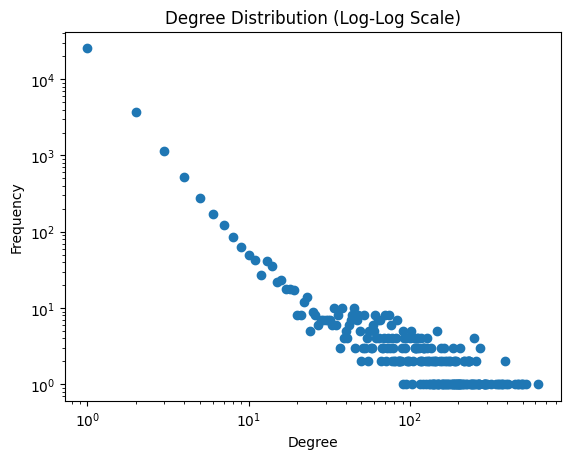

email, email-enron-large
Successfully downloaded email-enron-large network.
Network has 33698 nodes and 180813 edges.


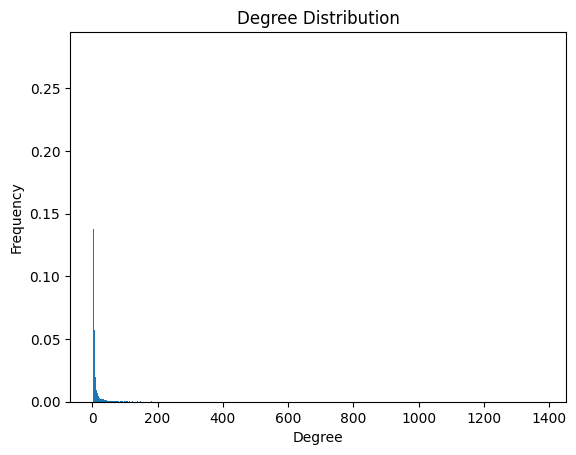

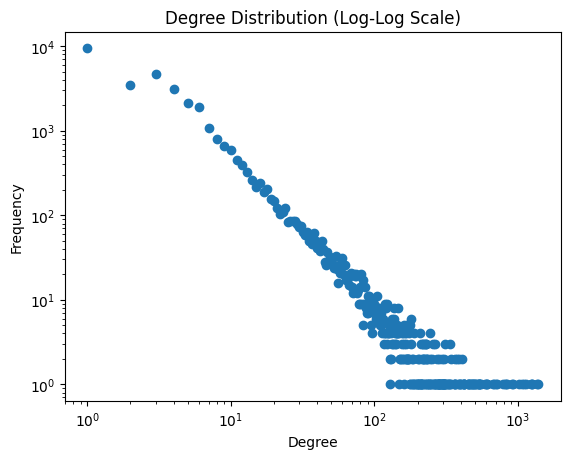

econ, econ-wm1
Successfully downloaded econ-wm1 network.
Network has 273 nodes and 2565 edges.


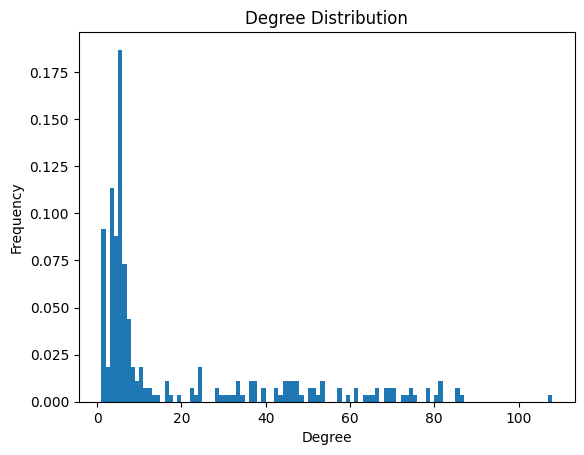

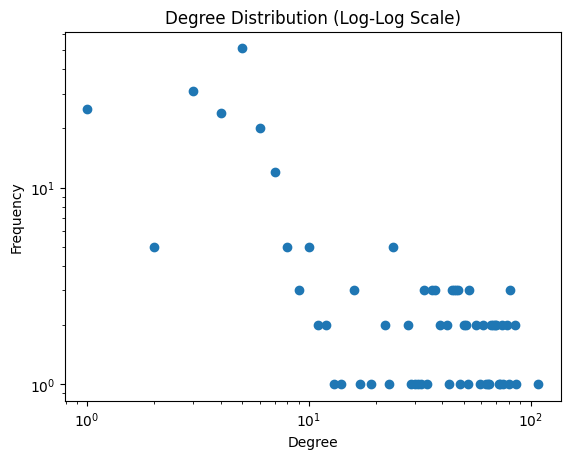

econ, econ-wm2
Successfully downloaded econ-wm2 network.
Network has 272 nodes and 2544 edges.


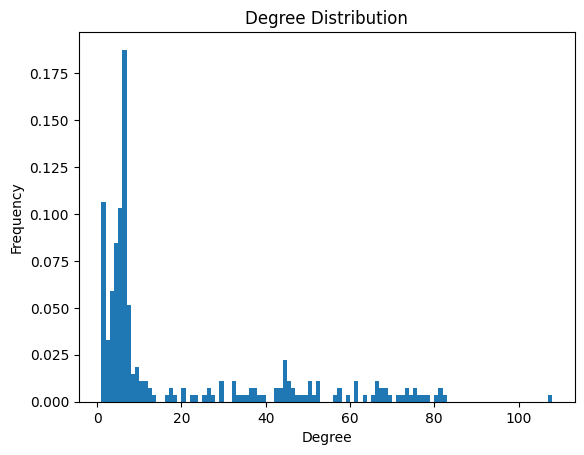

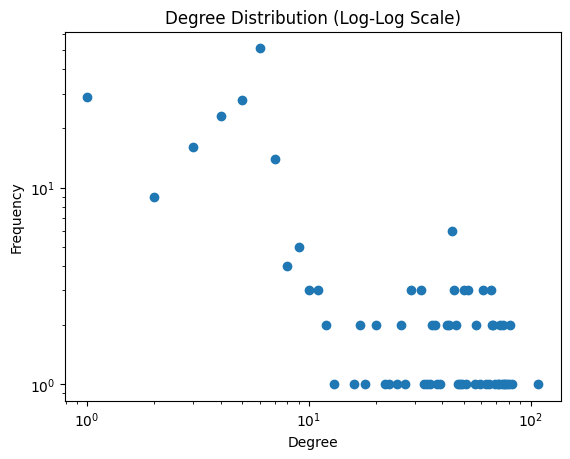

econ, econ-wm3
Successfully downloaded econ-wm3 network.
Network has 272 nodes and 2550 edges.


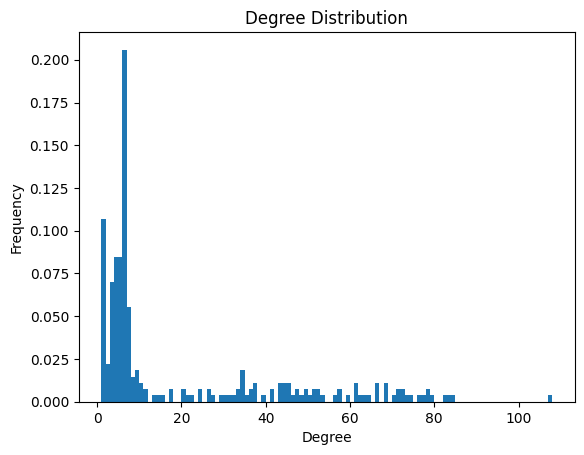

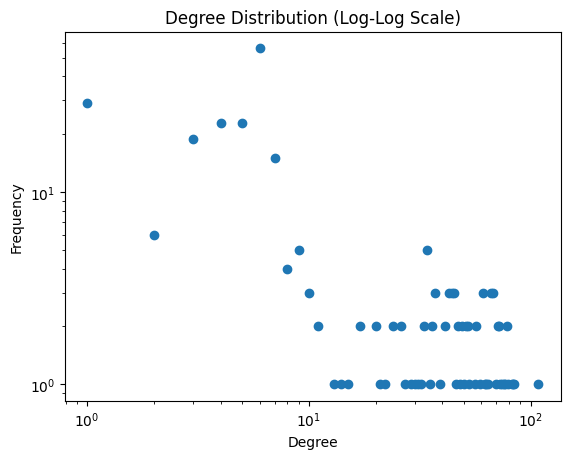

econ, econ-poli
Successfully downloaded econ-poli network.
Network has 4021 nodes and 8138 edges.


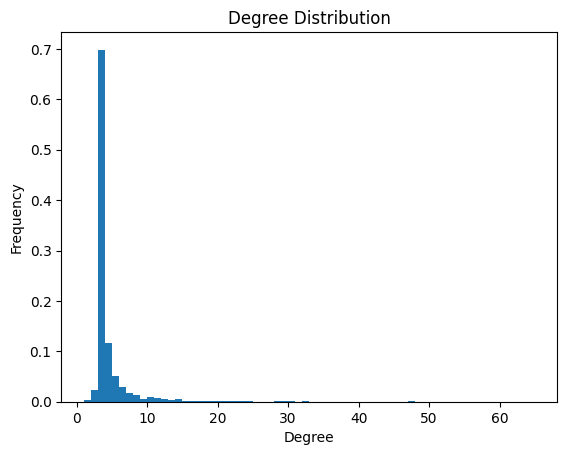

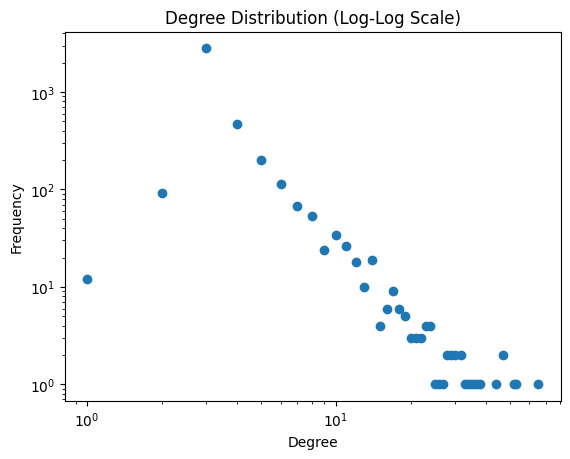

econ, econ-mahindas
Successfully downloaded econ-mahindas network.
Network has 1271 nodes and 7631 edges.


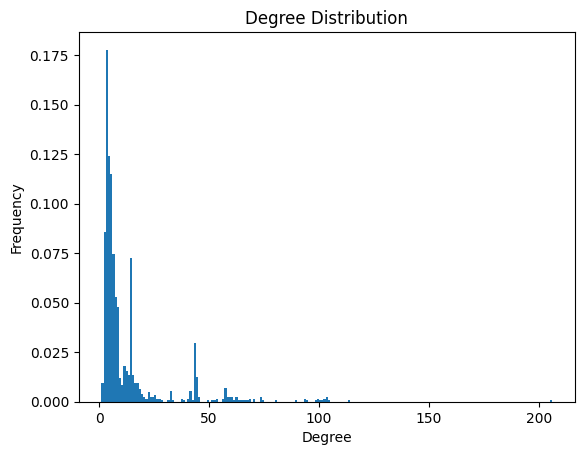

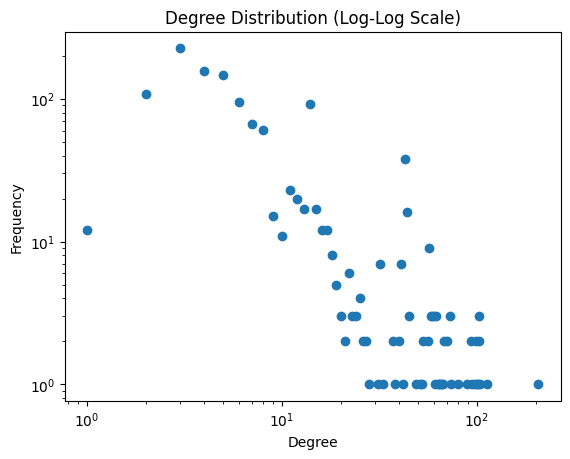

econ, econ-poli-large
Successfully downloaded econ-poli-large network.
Network has 15588 nodes and 33054 edges.


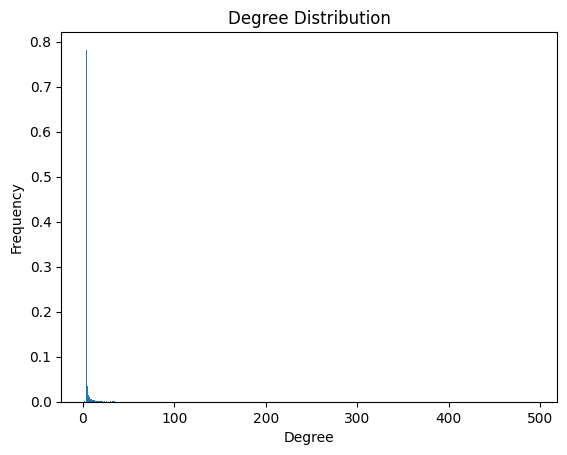

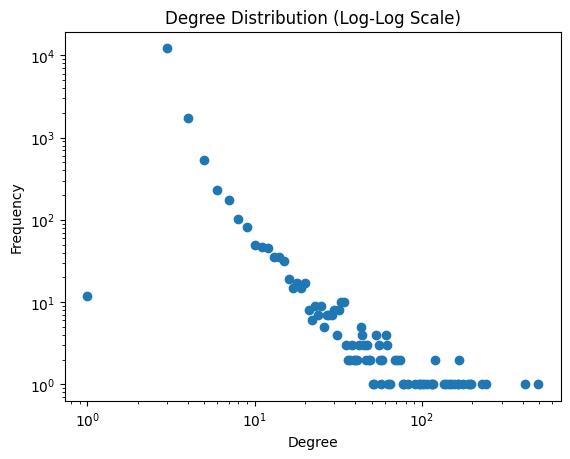

econ, econ-mbeause
Successfully downloaded econ-mbeause network.
Network has 506 nodes and 36621 edges.


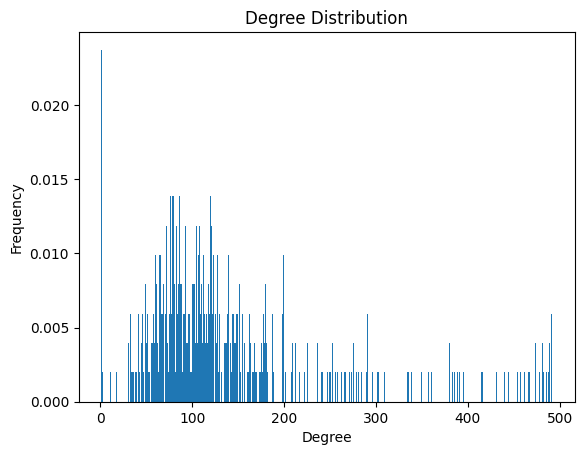

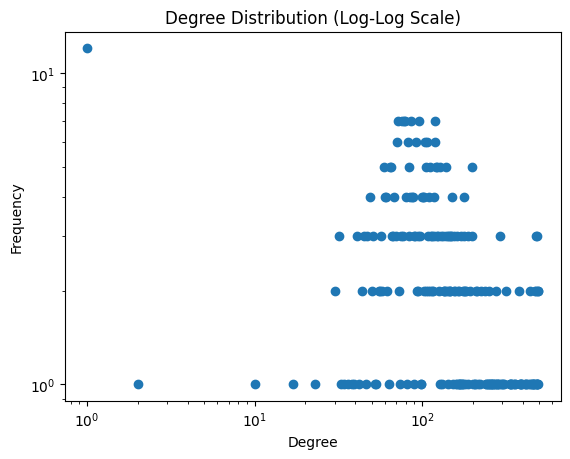

econ, econ-beause
Successfully downloaded econ-beause network.
Network has 520 nodes and 39839 edges.


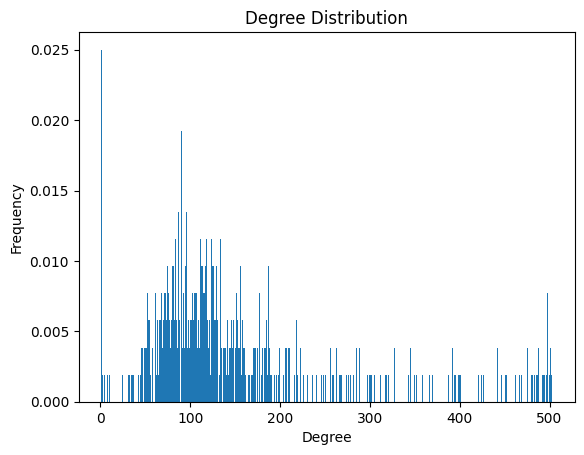

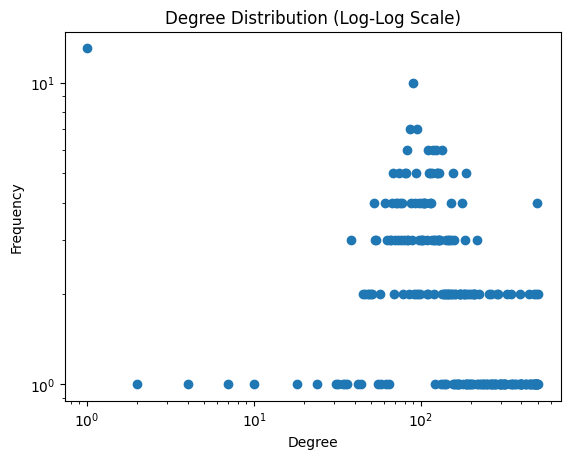

econ, econ-mbeaflw
Successfully downloaded econ-mbeaflw network.
Network has 501 nodes and 42102 edges.


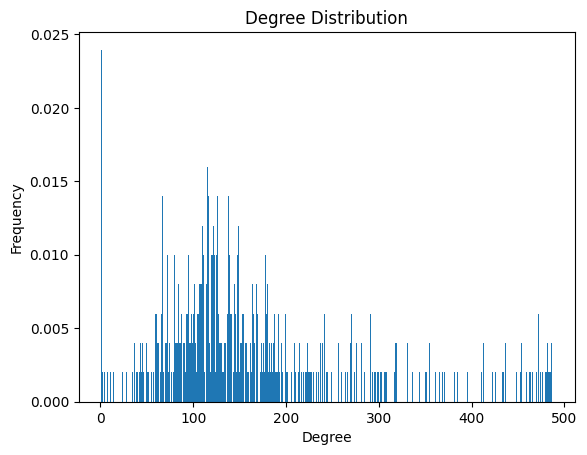

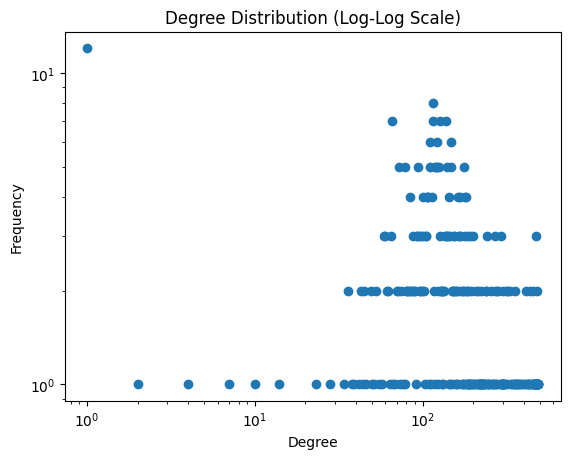

econ, econ-mbeacxc
Successfully downloaded econ-mbeacxc network.
Network has 501 nodes and 42102 edges.


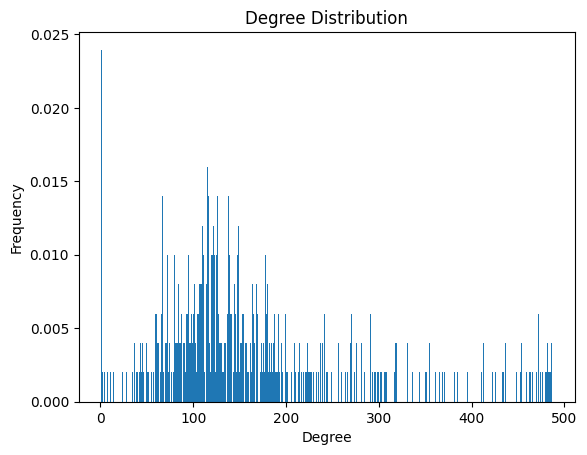

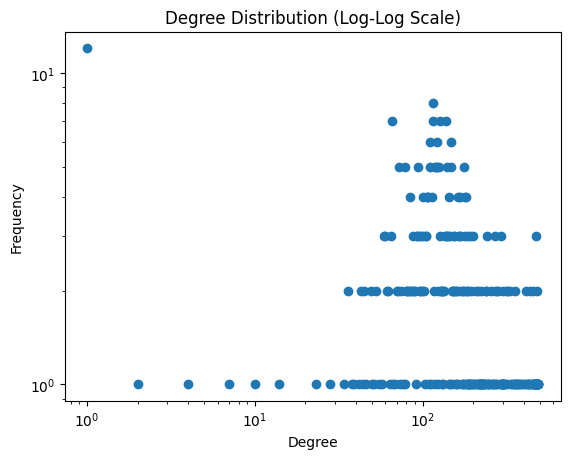

econ, econ-beacxc
Successfully downloaded econ-beacxc network.
Network has 506 nodes and 42591 edges.


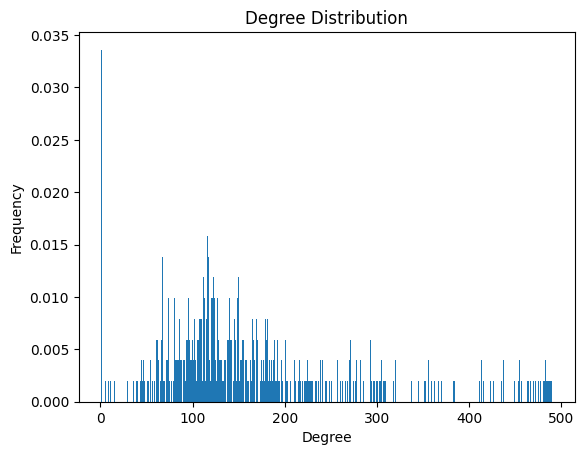

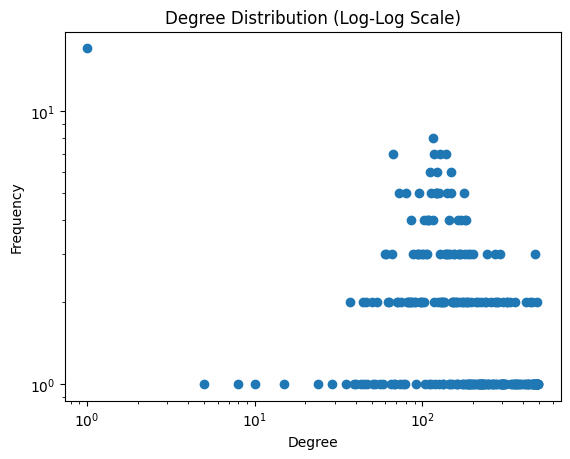

econ, econ-beaflw
Successfully downloaded econ-beaflw network.
Network has 515 nodes and 45315 edges.


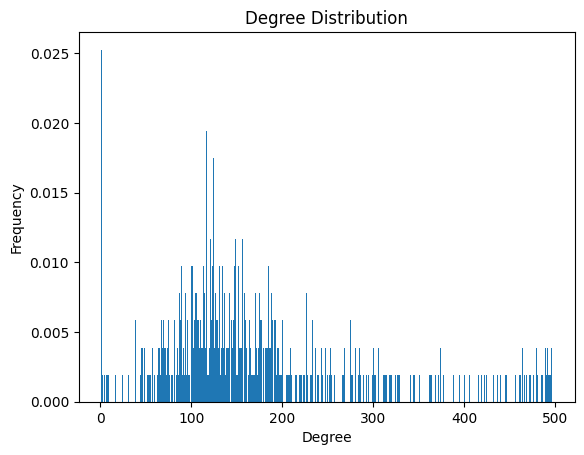

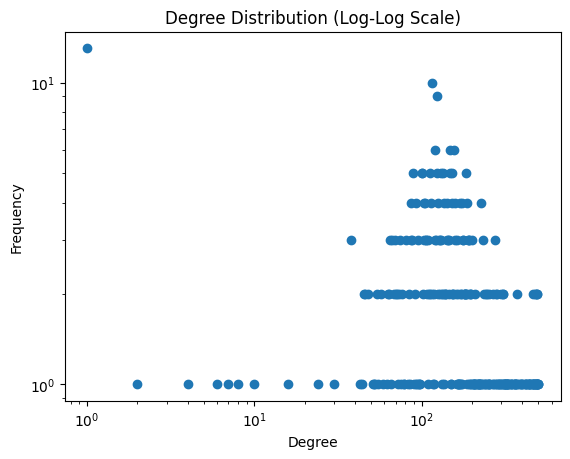

econ, econ-orani678
Successfully downloaded econ-orani678 network.
Network has 2542 nodes and 86991 edges.


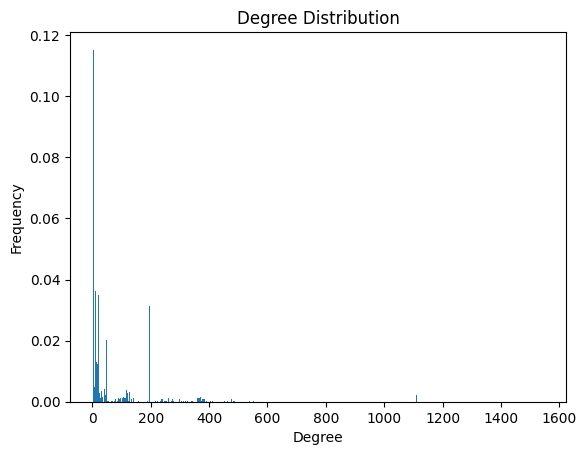

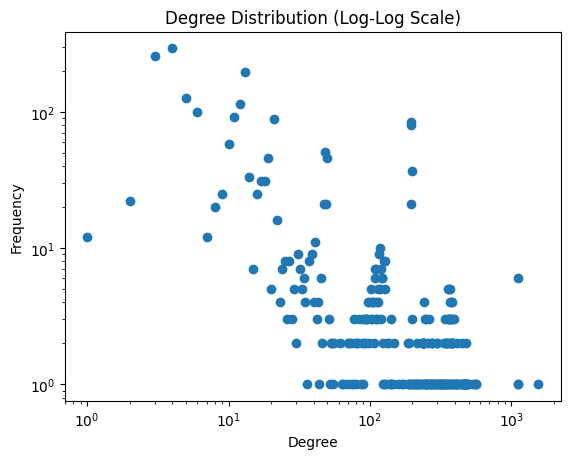

In [15]:
for category, sample_names in DATASET.items():
    for sample_names in sample_names:
        print(f"{category}, {sample_names}")
        network = download_network(category, sample_names)
        if network is None:
            continue

        match_network_model(network, {})